# Análise de Dados sobre Saúde Mental em Idosos
---
**Projeto:** Smart Analytics  
**Dataset:** `Dataset_Idosos.xlsx`  
**Trabalho realizado por:** Angelina Santos

---

## Resumo

Este _notebook_ apresenta uma análise exploratória e descritiva de um conjunto de dados relativo a idosos,
com foco em variáveis sociodemográficas, comportamentos de saúde (atividade física e sono) e indicadores
de saúde mental (PHQ-9 e GAD-7). O trabalho está organizado nas
seguintes secções:

1. Importação de Bibliotecas e Configuração  
2. Carregamento dos Dados  
3. Pré-processamento e Limpeza  
4. Análise Descritiva  
5. Análise Bivariada e Correlações  
6. Visualizações Avançadas  
7. Conclusões

---
> **Nota sobre os dados:** O _dataset_ contém 3915 observações e 17 variáveis relativas a participantes
> com idades compreendidas entre os 63 e os 90 anos. As variáveis categóricas estão codificadas
> numericamente e serão mapeadas para valores legíveis ao longo da análise.


---
## 1. Importação de Bibliotecas e Configuração

Nesta secção, importam-se todas as bibliotecas necessárias para a análise e configuram-se os
parâmetros globais de visualização.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Estatística
from scipy import stats
from scipy.stats import shapiro, mannwhitneyu, kruskal, spearmanr

# Utilitários
import warnings
warnings.filterwarnings('ignore')

# ── Configuração global dos gráficos ──────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (10, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

PALETA_GENERO = {'Masculino': '#4C72B0', 'Feminino': '#DD8452'}
PALETA_ESTADO = sns.color_palette('Set2', 4)
SEED          = 42

print("✔  Bibliotecas importadas com sucesso.")
print(f"   pandas  {pd.__version__}  |  numpy  {np.__version__}  |  seaborn  {sns.__version__}")


✔  Bibliotecas importadas com sucesso.
   pandas  2.2.2  |  numpy  2.0.2  |  seaborn  0.13.2


---
## 2. Carregamento dos Dados



In [3]:
# ── Carregamento ──────────────────────────────────────────────────────────
df_raw = pd.read_csv('/content/drive/MyDrive/IACD/Projeto/notebooks/Dataset_Idosos.csv', sep=';')

print(f"Dimensões do dataset: {df_raw.shape[0]} linhas × {df_raw.shape[1]} colunas")
print("\nPrimeiras 5 linhas:")
df_raw.head()


Dimensões do dataset: 3915 linhas × 16 colunas

Primeiras 5 linhas:


,participant_id,age,gender,education_years,monthly_income,marital_status,living_situation,comorbidities_count,physical_activity_days_per_week,physical_activity_minutes_per_session,physical_activity_total_minutes_week,physical_activity_type,physical_activity_intensity,sleep_hours,phq9_total,gad7_total
0,1,65,1,3,950.15,1,1,1.0,7.0,52.0,364.0,1.0,2.0,7.9,0.0,0.0
1,2,71,1,6,1600.25,1,1,2.0,5.0,37.0,185.0,1.0,2.0,7.2,1.0,1.0
2,3,68,2,7,1800.10,2,2,2.0,6.0,43.0,258.0,1.0,2.0,7.4,2.0,2.0
3,4,70,2,5,1350.35,1,1,2.0,5.0,35.0,175.0,1.0,2.0,7.0,1.0,1.0
4,5,68,1,14,4500.20,2,2,2.0,7.0,45.0,315.0,5.0,3.0,7.6,2.0,2.0


In [4]:
# ── Tipos de dados e valores em falta ────────────────────────────────────
info_df = pd.DataFrame({
    'Tipo'             : df_raw.dtypes,
    'Valores em Falta' : df_raw.isnull().sum(),
    '% em Falta'       : (df_raw.isnull().mean() * 100).round(2),
    'Valores Únicos'   : df_raw.nunique()
})
print("Informação sobre as variáveis:\n")
info_df


Informação sobre as variáveis:



,Tipo,Valores em Falta,% em Falta,Valores Únicos
participant_id,int64,0,0.0,3915
age,int64,0,0.0,28
gender,int64,0,0.0,2
education_years,int64,0,0.0,15
monthly_income,float64,0,0.0,1532
marital_status,int64,0,0.0,4
living_situation,int64,0,0.0,4
comorbidities_count,float64,0,0.0,13
physical_activity_days_per_week,float64,0,0.0,8
physical_activity_minutes_per_session,float64,0,0.0,55


In [5]:
# ── Estatísticas descritivas iniciais ────────────────────────────────────
print("Estatísticas descritivas das variáveis numéricas:\n")
df_raw.describe().T.style.format(precision=2).background_gradient(cmap='Blues', axis=1)


Estatísticas descritivas das variáveis numéricas:



,count,mean,std,min,25%,50%,75%,max
participant_id,3915.00,1958.00,1130.31,1.00,979.50,1958.00,2936.50,3915.00
age,3915.00,74.74,5.32,63.00,71.00,75.00,79.00,90.00
gender,3915.00,1.53,0.50,1.00,1.00,2.00,2.00,2.00
education_years,3915.00,7.88,2.91,2.00,6.00,8.00,10.00,16.00
monthly_income,3915.00,2819.31,1090.70,350.00,1950.15,2700.27,3650.88,5900.88
marital_status,3915.00,2.34,0.88,1.00,2.00,2.00,3.00,4.00
living_situation,3915.00,2.30,0.87,1.00,2.00,2.00,3.00,4.00
comorbidities_count,3915.00,3.12,1.60,0.00,2.00,3.00,4.00,12.00
physical_activity_days_per_week,3915.00,4.04,2.17,0.00,3.00,5.00,6.00,7.00
physical_activity_minutes_per_session,3915.00,30.92,14.86,0.00,26.00,35.00,41.00,62.00


---
## 3. Pré-processamento e Limpeza




Esta secção abrange todas as etapas de preparação dos dados antes da análise, nomeadamente:

- Mapeamento de variáveis categóricas codificadas numericamente  
- Tratamento de valores em falta  
- Criação de variáveis derivadas  
- Deteção e tratamento de *outliers*  
- Verificação da consistência dos dados



### 3.1 Mapeamento de Variáveis Categóricas



As variáveis categóricas foram codificadas numericamente no _dataset_ original.
Com base no domínio do problema, efetua-se o mapeamento para etiquetas descritivas.

In [6]:
df = df_raw.copy()

# ── Dicionários de mapeamento ─────────────────────────────────────────────
MAP_GENERO = {1: 'Masculino', 2: 'Feminino'}

MAP_ESTADO_CIVIL = {
    1: 'Solteiro/a',
    2: 'Casado/a',
    3: 'Divorciado/a',
    4: 'Viúvo/a'
}

MAP_SITUACAO_HABITACIONAL = {
    1: 'Sozinho/a',
    2: 'Com parceiro/a',
    3: 'Com família',
    4: 'Instituição'
}

MAP_TIPO_ATIVIDADE = {
    0: 'Nenhuma',
    1: 'Caminhada',
    2: 'Exercício leve',
    3: 'Doméstica/jardinagem',
    4: 'Exercício moderado',
    5: 'Exercício vigoroso'
}

MAP_INTENSIDADE = {
    0: 'Nenhuma',
    1: 'Leve',
    2: 'Moderada',
    3: 'Vigorosa'
}

# ── Aplicação dos mapeamentos ─────────────────────────────────────────────
df['genero_cat']       = df['gender'].map(MAP_GENERO)
df['estado_civil_cat'] = df['marital_status'].map(MAP_ESTADO_CIVIL)
df['habitacao_cat']    = df['living_situation'].map(MAP_SITUACAO_HABITACIONAL)
df['tipo_ativ_cat']    = df['physical_activity_type'].map(MAP_TIPO_ATIVIDADE)
df['intensidade_cat']  = df['physical_activity_intensity'].map(MAP_INTENSIDADE)

print("✔  Variáveis categóricas mapeadas.")
print("\nDistribuição do género:")
print(df['genero_cat'].value_counts())


✔  Variáveis categóricas mapeadas.

Distribuição do género:
genero_cat
Feminino     2058
Masculino    1857
Name: count, dtype: int64


### 3.2 Tratamento de Valores em Falta

O _dataset_ apresenta poucos valores em falta (máximo 2 por variável, representando menos de 0,35 % das observações).
Dado o número reduzido, recorre-se à imputação pela mediana para variáveis numéricas contínuas,
estratégia robusta à presença de *outliers* e adequada a amostras pequenas de dados em falta.


In [7]:
# ── Identificação das colunas com valores em falta ────────────────────────
colunas_com_na = df_raw.columns[df_raw.isnull().any()].tolist()
print("Colunas com valores em falta:", colunas_com_na)
print()

# ── Imputação pela mediana ────────────────────────────────────────────────
for col in colunas_com_na:
    mediana = df[col].median()
    n_imputados = df[col].isnull().sum()
    df[col] = df[col].fillna(mediana)
    print(f"  '{col}': {n_imputados} valor(es) imputado(s) com mediana = {mediana:.2f}")

print()
print(f"✔  Total de valores em falta após imputação: {df.isnull().sum().sum()}")


Colunas com valores em falta: []


✔  Total de valores em falta após imputação: 0


In [8]:
df.isnull().sum()

,0
participant_id,0
age,0
gender,0
education_years,0
monthly_income,0
marital_status,0
living_situation,0
comorbidities_count,0
physical_activity_days_per_week,0
physical_activity_minutes_per_session,0


### 3.3 Criação de Variáveis Derivadas

Criam-se novas variáveis que facilitam a análise e a interpretação clínica dos resultados:

- **Grupo etário** — segmentação da idade em intervalos de 5 anos  
- **Ativo fisicamente** — variável binária com base nas recomendações da OMS (≥ 150 min/semana)  
- **Classificação PHQ-9** — categorização da gravidade da depressão segundo o PHQ-9 padrão  
- **Classificação GAD-7** — categorização da gravidade da ansiedade segundo o GAD-7 padrão  


In [9]:
# ── Grupo etário ──────────────────────────────────────────────────────────
bins_idade   = [63, 69, 74, 79, 84, 90]
labels_idade = ['63–69', '70–74', '75–79', '80–84', '85–90']
df['grupo_etario'] = pd.cut(df['age'], bins=bins_idade, labels=labels_idade, right=True)

# ── Atividade física (≥150 min/semana = recomendação OMS) ────────────────
df['activo_fisicamente'] = (df['physical_activity_total_minutes_week'] >= 150).map(
    {True: 'Ativo', False: 'Insuficientemente ativo'}
)

# ── Classificação PHQ-9 ───────────────────────────────────────────────────
# 0-4: Mínima | 5-9: Leve | 10-14: Moderada | 15-19: Mod. grave | 20-27: Grave
bins_phq9   = [-1, 4, 9, 14, 19, 27]
labels_phq9 = ['Mínima', 'Leve', 'Moderada', 'Mod. grave', 'Grave']
df['phq9_classe'] = pd.cut(df['phq9_total'], bins=bins_phq9, labels=labels_phq9)

# ── Classificação GAD-7 ───────────────────────────────────────────────────
# 0-4: Mínima | 5-9: Leve | 10-14: Moderada | 15-21: Grave
bins_gad7   = [-1, 4, 9, 14, 21]
labels_gad7 = ['Mínima', 'Leve', 'Moderada', 'Grave']
df['gad7_classe'] = pd.cut(df['gad7_total'], bins=bins_gad7, labels=labels_gad7)


print("✔  Variáveis derivadas criadas com sucesso.")
print(f"   Participantes ativos fisicamente (OMS):  {(df['activo_fisicamente']=='Ativo').sum()} ({(df['activo_fisicamente']=='Ativo').mean()*100:.1f} %)")

✔  Variáveis derivadas criadas com sucesso.
   Participantes ativos fisicamente (OMS):  2184 (55.8 %)


### 3.4 Deteção e Tratamento de *Outliers*

Utiliza-se o método do **Intervalo Interquartílico (IQR)** para identificar valores atípicos
nas variáveis numéricas contínuas.
Os _outliers_ são apenas identificados e documentados, não serão removidos nem tratados pois são casos atípicos, sendo significativamente relevantes para a análise.


In [10]:
variaveis_numericas = [
    'age', 'education_years', 'monthly_income', 'comorbidities_count',
    'physical_activity_total_minutes_week', 'sleep_hours',
    'phq9_total', 'gad7_total'
]

resumo_outliers = []
for col in variaveis_numericas:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    resumo_outliers.append({
        'Variável': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lim. Inferior': lim_inf, 'Lim. Superior': lim_sup, 'Nº Outliers': n_out
    })

outliers_df = pd.DataFrame(resumo_outliers).set_index('Variável')
print("Resumo de outliers pelo método IQR:\n")
outliers_df.style.format(precision=2).highlight_between(
    subset=['Nº Outliers'], left=1, right=1000,
    props='background-color: #ffe0b2; color: black;'
)


Resumo de outliers pelo método IQR:



,Q1,Q3,IQR,Lim. Inferior,Lim. Superior,Nº Outliers
Variável,,,,,,
age,71.00,79.00,8.00,59.00,91.00,0
education_years,6.00,10.00,4.00,0.00,16.00,0
monthly_income,1950.15,3650.88,1700.73,-600.95,6201.98,0
comorbidities_count,2.00,4.00,2.00,-1.00,7.00,62
physical_activity_total_minutes_week,72.00,234.00,162.00,-171.00,477.00,0
sleep_hours,6.50,7.20,0.70,5.45,8.25,576
phq9_total,3.00,11.00,8.00,-9.00,23.00,187
gad7_total,2.00,9.00,7.00,-8.50,19.50,80


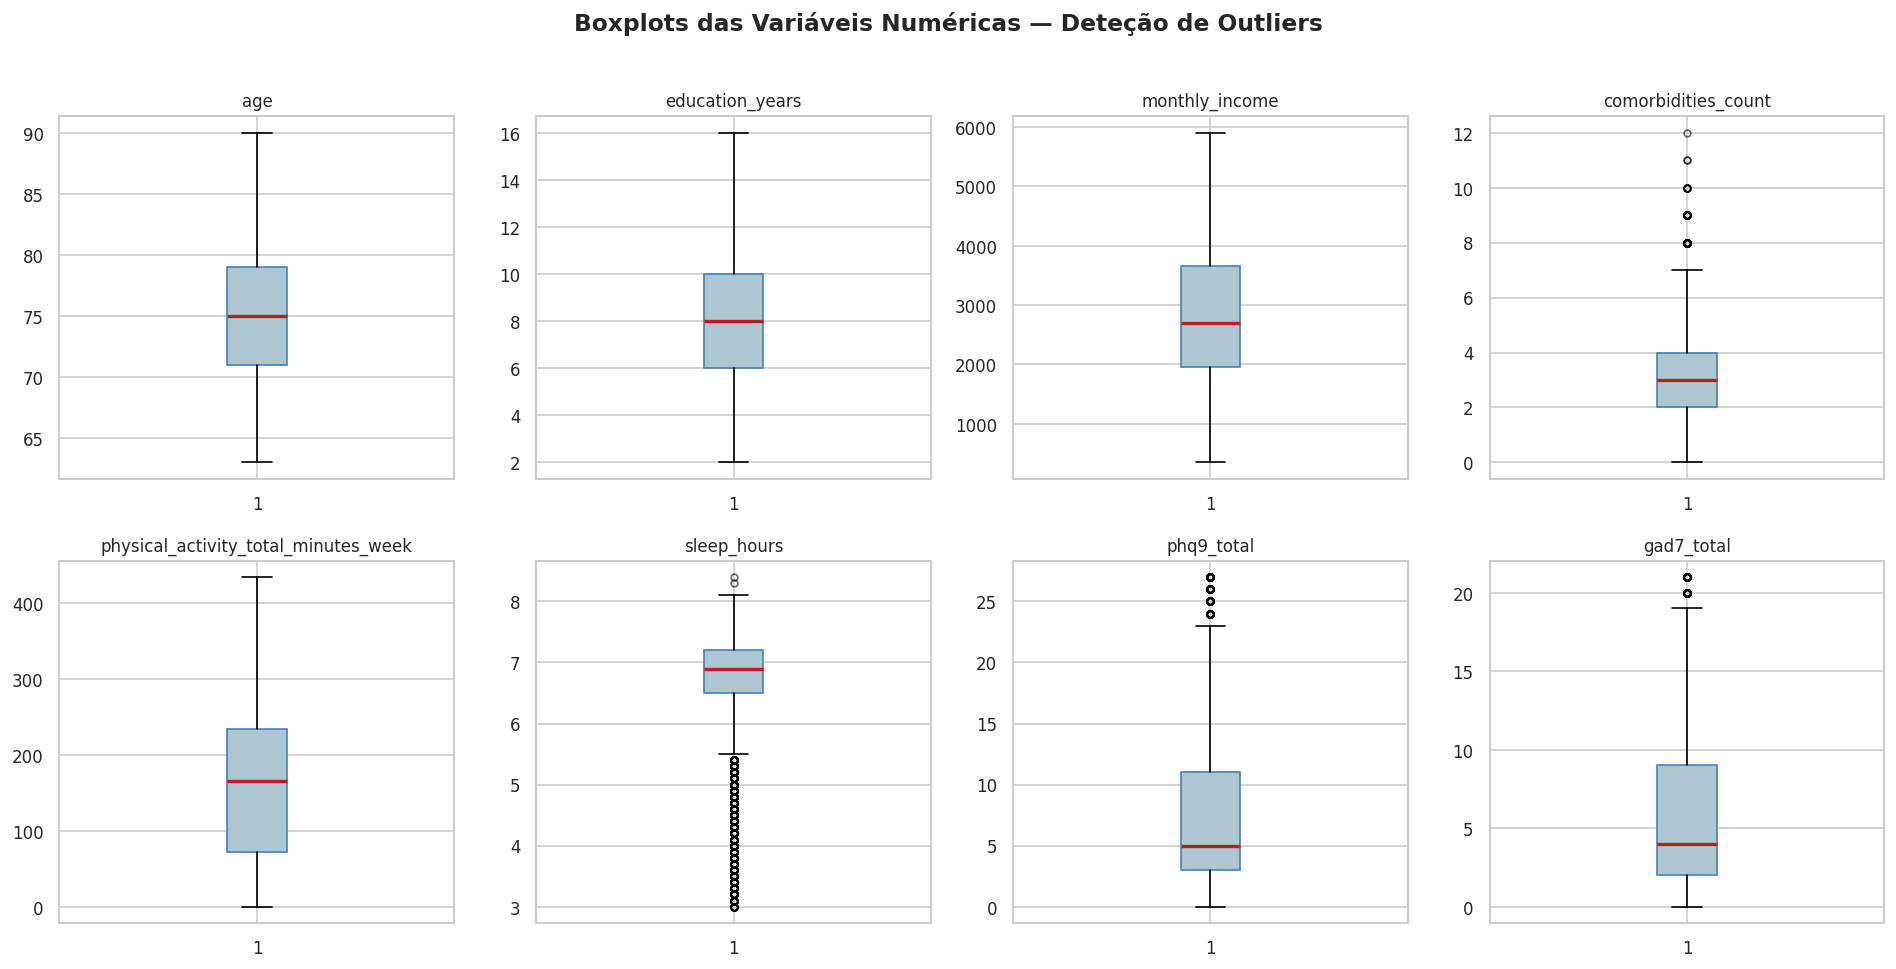

In [11]:
# ── Visualização de outliers com boxplots ─────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(variaveis_numericas):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#AEC6CF', color='steelblue'),
                    medianprops=dict(color='firebrick', linewidth=2),
                    flierprops=dict(marker='o', color='orange', markersize=4, alpha=0.6))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

fig.suptitle('Boxplots das Variáveis Numéricas — Deteção de Outliers',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 4. Análise Descritiva




### 4.1 Caracterização Sociodemográfica da Amostra



Analisa-se a distribuição das principais variáveis sociodemográficas: idade, género,
estado civil, situação habitacional, escolaridade e rendimento mensal.

In [12]:
print("=" * 60)
print("CARACTERIZAÇÃO DA AMOSTRA (N = {:,})".format(len(df)).center(60))
print("=" * 60)

print("\n── Idade ─────────────────────────────────────────────────")
print(df['age'].describe().rename({
    'count':'N', 'mean':'Média', 'std':'Desvio Padrão', 'min':'Mín.',
    '25%':'25%', '50%':'Mediana', '75%':'75%', 'max':'Máx.'
}).round(2).to_string())

print("\n── Género ────────────────────────────────────────────────")
for k, v in df['genero_cat'].value_counts().items():
    print(f"  {k}: {v} ({v/len(df)*100:.1f} %)")

print("\n── Estado Civil ──────────────────────────────────────────")
for k, v in df['estado_civil_cat'].value_counts().items():
    print(f"  {k}: {v} ({v/len(df)*100:.1f} %)")

print("\n── Situação Habitacional ─────────────────────────────────")
for k, v in df['habitacao_cat'].value_counts().items():
    print(f"  {k}: {v} ({v/len(df)*100:.1f} %)")

print("\n── Escolaridade (anos) ───────────────────────────────────")
print(df['education_years'].describe()[['mean','std','min','max']].round(2).to_string())

print("\n── Rendimento Mensal (€) ─────────────────────────────────")
print(df['monthly_income'].describe()[['mean','std','min','max']].round(2).to_string())


           CARACTERIZAÇÃO DA AMOSTRA (N = 3,915)            

── Idade ─────────────────────────────────────────────────
N                3915.00
Média              74.74
Desvio Padrão       5.32
Mín.               63.00
25%                71.00
Mediana            75.00
75%                79.00
Máx.               90.00

── Género ────────────────────────────────────────────────
  Feminino: 2058 (52.6 %)
  Masculino: 1857 (47.4 %)

── Estado Civil ──────────────────────────────────────────
  Casado/a: 2522 (64.4 %)
  Viúvo/a: 701 (17.9 %)
  Solteiro/a: 389 (9.9 %)
  Divorciado/a: 303 (7.7 %)

── Situação Habitacional ─────────────────────────────────
  Com parceiro/a: 2461 (62.9 %)
  Instituição: 631 (16.1 %)
  Sozinho/a: 451 (11.5 %)
  Com família: 372 (9.5 %)

── Escolaridade (anos) ───────────────────────────────────
mean     7.88
std      2.91
min      2.00
max     16.00

── Rendimento Mensal (€) ─────────────────────────────────
mean    2819.31
std     1090.70
min      350.00
max  

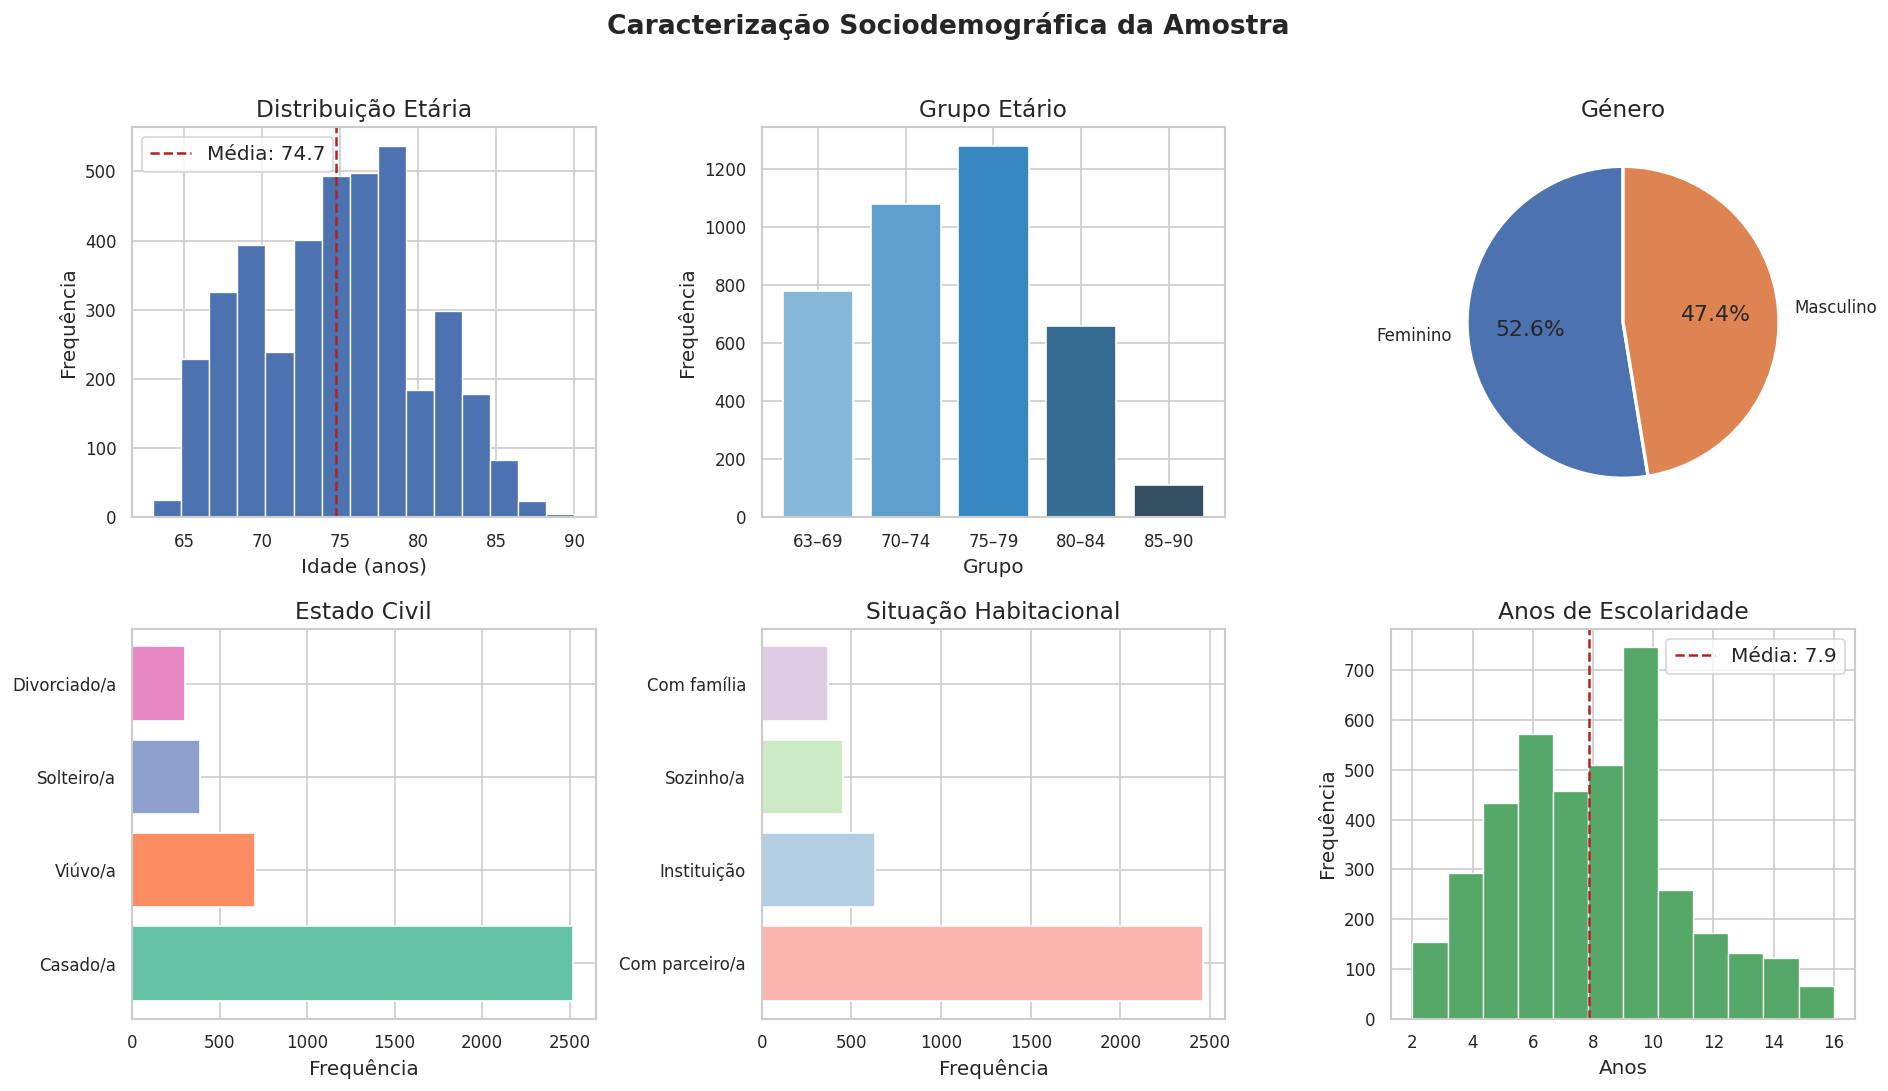

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Distribuição etária
axes[0, 0].hist(df['age'], bins=15, color='#4C72B0', edgecolor='white', linewidth=0.8)
axes[0, 0].set_title('Distribuição Etária')
axes[0, 0].set_xlabel('Idade (anos)')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].axvline(df['age'].mean(), color='firebrick', linestyle='--',
                   label=f"Média: {df['age'].mean():.1f}")
axes[0, 0].legend()

# 2. Grupo etário
contagem_ge = df['grupo_etario'].value_counts().reindex(labels_idade)
axes[0, 1].bar(contagem_ge.index, contagem_ge.values,
               color=sns.color_palette('Blues_d', len(labels_idade)))
axes[0, 1].set_title('Grupo Etário')
axes[0, 1].set_xlabel('Grupo')
axes[0, 1].set_ylabel('Frequência')

# 3. Género (pizza)
gen_counts = df['genero_cat'].value_counts()
axes[0, 2].pie(gen_counts, labels=gen_counts.index, autopct='%1.1f%%',
               colors=[PALETA_GENERO['Masculino'], PALETA_GENERO['Feminino']],
               startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0, 2].set_title('Género')

# 4. Estado civil
ec_counts = df['estado_civil_cat'].value_counts()
axes[1, 0].barh(ec_counts.index, ec_counts.values,
                color=sns.color_palette('Set2', len(ec_counts)))
axes[1, 0].set_title('Estado Civil')
axes[1, 0].set_xlabel('Frequência')

# 5. Situação habitacional
sh_counts = df['habitacao_cat'].value_counts()
axes[1, 1].barh(sh_counts.index, sh_counts.values,
                color=sns.color_palette('Pastel1', len(sh_counts)))
axes[1, 1].set_title('Situação Habitacional')
axes[1, 1].set_xlabel('Frequência')

# 6. Escolaridade
axes[1, 2].hist(df['education_years'], bins=12, color='#55A868',
                edgecolor='white', linewidth=0.8)
axes[1, 2].set_title('Anos de Escolaridade')
axes[1, 2].set_xlabel('Anos')
axes[1, 2].set_ylabel('Frequência')
axes[1, 2].axvline(df['education_years'].mean(), color='firebrick', linestyle='--',
                   label=f"Média: {df['education_years'].mean():.1f}")
axes[1, 2].legend()

fig.suptitle('Caracterização Sociodemográfica da Amostra',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 4.2 Análise da Atividade Física e Sono

Descreve-se o padrão de atividade física (frequência semanal, duração, tipo e intensidade)
e os hábitos de sono da amostra.


In [14]:
print("ATIVIDADE FÍSICA E SONO".center(60, "─"))
print()
print("Minutos totais por semana:")
print(df['physical_activity_total_minutes_week'].describe().round(2).to_string())
print()
print(f"Ativos segundo a OMS (≥150 min/sem):")
print(df['activo_fisicamente'].value_counts().to_string())
print()
print("Tipo de atividade mais frequente:")
print(df['tipo_ativ_cat'].value_counts().to_string())
print()
print("Intensidade praticada:")
print(df['intensidade_cat'].value_counts().to_string())
print()
print("Horas de sono — estatísticas:")
print(df['sleep_hours'].describe().round(2).to_string())


──────────────────ATIVIDADE FÍSICA E SONO───────────────────

Minutos totais por semana:
count    3915.00
mean      154.45
std       100.27
min         0.00
25%        72.00
50%       165.00
75%       234.00
max       434.00

Ativos segundo a OMS (≥150 min/sem):
activo_fisicamente
Ativo                      2184
Insuficientemente ativo    1731

Tipo de atividade mais frequente:
tipo_ativ_cat
Caminhada               1853
Exercício leve           604
Doméstica/jardinagem     598
Nenhuma                  550
Exercício vigoroso       180
Exercício moderado       130

Intensidade praticada:
intensidade_cat
Leve        2047
Moderada    1138
Nenhuma      550
Vigorosa     180

Horas de sono — estatísticas:
count    3915.00
mean        6.55
std         1.04
min         3.00
25%         6.50
50%         6.90
75%         7.20
max         8.40


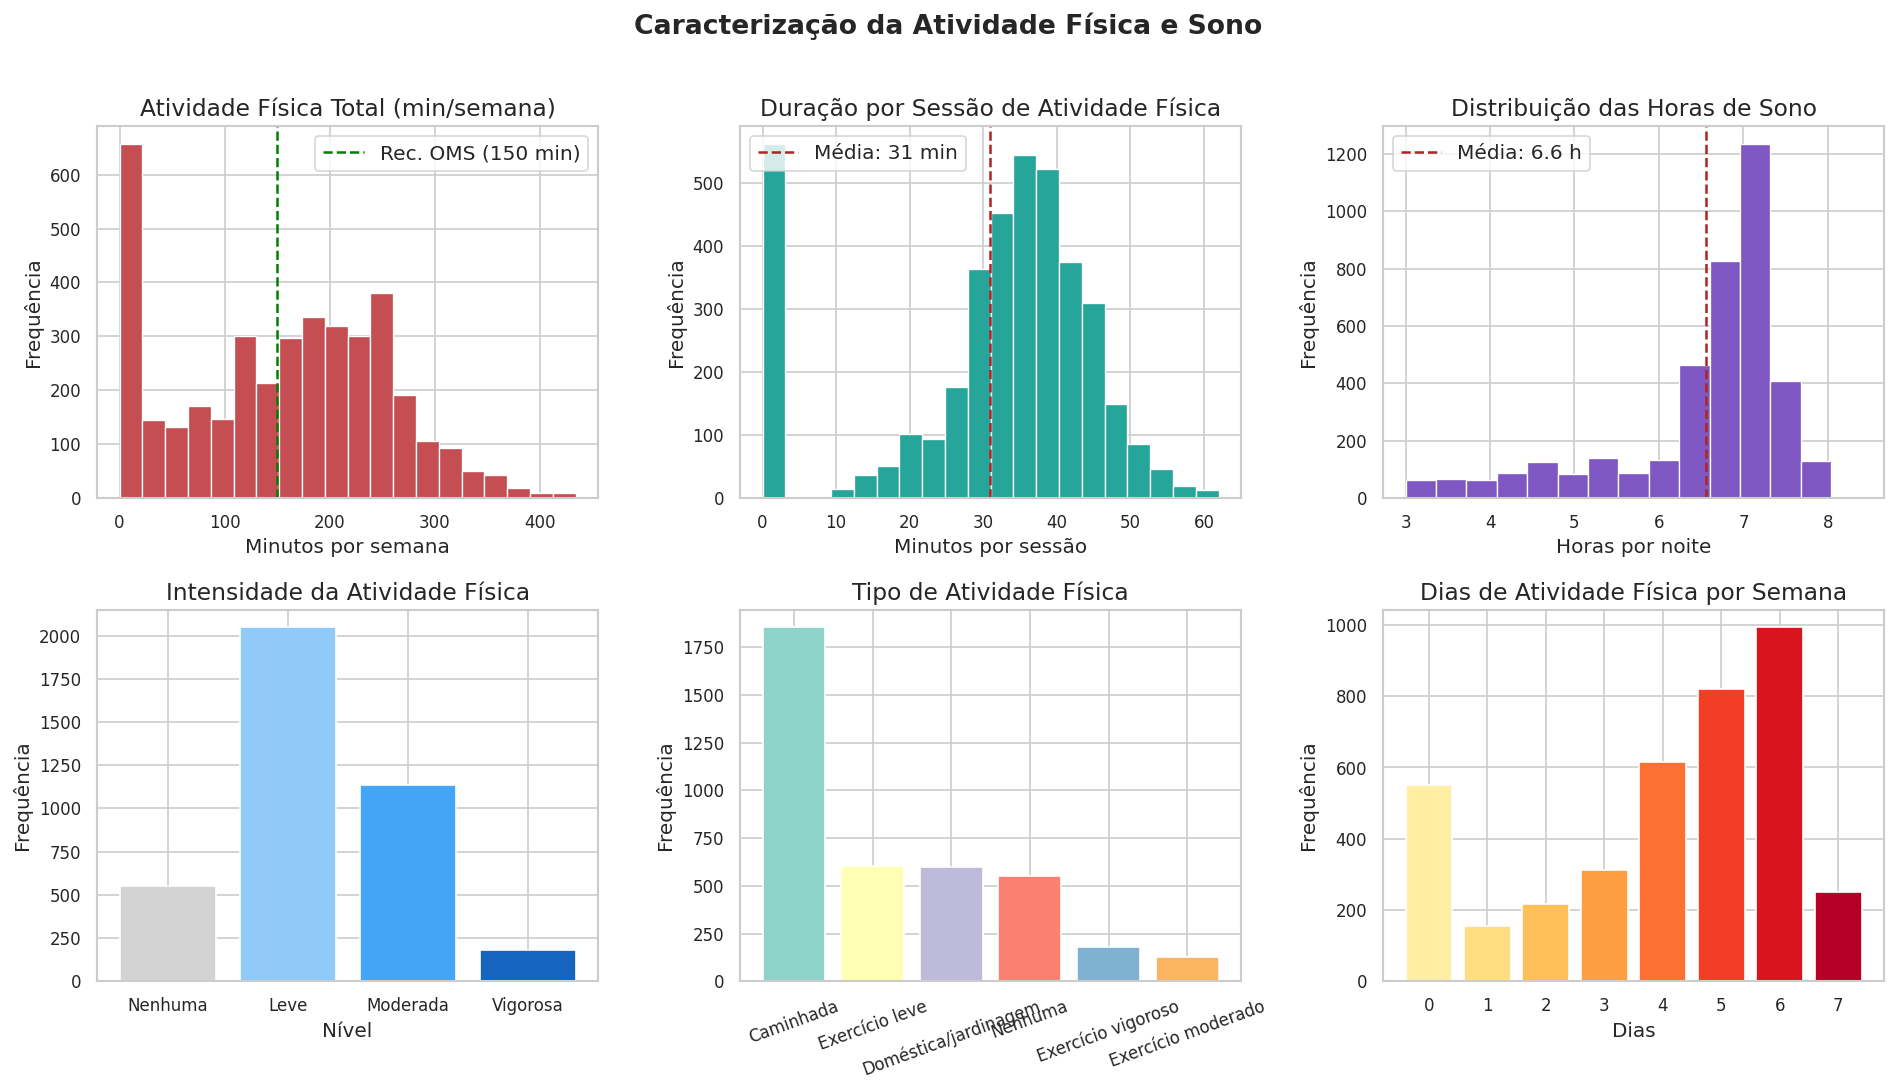

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Linha 1
axes[0, 0].hist(df['physical_activity_total_minutes_week'], bins=20,
                color='#C44E52', edgecolor='white', linewidth=0.8)
axes[0, 0].axvline(150, color='green', linestyle='--', linewidth=1.5,
                   label='Rec. OMS (150 min)')
axes[0, 0].set_title('Atividade Física Total (min/semana)')
axes[0, 0].set_xlabel('Minutos por semana')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].legend()

axes[0, 1].hist(df['physical_activity_minutes_per_session'], bins=20,
                color='#26A69A', edgecolor='white', linewidth=0.8)
axes[0, 1].axvline(df['physical_activity_minutes_per_session'].mean(),
                   color='firebrick', linestyle='--',
                   label=f"Média: {df['physical_activity_minutes_per_session'].mean():.0f} min")
axes[0, 1].set_title('Duração por Sessão de Atividade Física')
axes[0, 1].set_xlabel('Minutos por sessão')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].legend()

axes[0, 2].hist(df['sleep_hours'], bins=15, color='#7E57C2',
                edgecolor='white', linewidth=0.8)
axes[0, 2].axvline(df['sleep_hours'].mean(), color='firebrick', linestyle='--',
                   label=f"Média: {df['sleep_hours'].mean():.1f} h")
axes[0, 2].set_title('Distribuição das Horas de Sono')
axes[0, 2].set_xlabel('Horas por noite')
axes[0, 2].set_ylabel('Frequência')
axes[0, 2].legend()

# Linha 2
int_counts = df['intensidade_cat'].value_counts().reindex(
    ['Nenhuma','Leve','Moderada','Vigorosa'])
axes[1, 0].bar(int_counts.index, int_counts.values,
               color=['#d3d3d3','#90CAF9','#42A5F5','#1565C0'])
axes[1, 0].set_title('Intensidade da Atividade Física')
axes[1, 0].set_xlabel('Nível')
axes[1, 0].set_ylabel('Frequência')

tipo_counts = df['tipo_ativ_cat'].value_counts()
axes[1, 1].bar(tipo_counts.index, tipo_counts.values,
               color=sns.color_palette('Set3'))
axes[1, 1].set_title('Tipo de Atividade Física')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].tick_params(axis='x', rotation=20)

dias_counts = df['physical_activity_days_per_week'].value_counts().sort_index()
axes[1, 2].bar(dias_counts.index.astype(int), dias_counts.values,
               color=sns.color_palette('YlOrRd', len(dias_counts)))
axes[1, 2].set_title('Dias de Atividade Física por Semana')
axes[1, 2].set_xlabel('Dias')
axes[1, 2].set_ylabel('Frequência')

fig.suptitle('Caracterização da Atividade Física e Sono',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Análise dos Indicadores de Saúde Mental

Analisa-se a distribuição dos _scores_ do **PHQ-9** (depressão) e **GAD-7** (ansiedade).


In [16]:
print("INDICADORES DE SAÚDE MENTAL".center(60, "─"))
print()
print("PHQ-9 (depressão):")
print(df['phq9_total'].describe().round(2).to_string())
print()
print("Classificação PHQ-9:")
print(df['phq9_classe'].value_counts().sort_index().to_string())
print()
print("GAD-7 (ansiedade):")
print(df['gad7_total'].describe().round(2).to_string())
print()
print("Classificação GAD-7:")
print(df['gad7_classe'].value_counts().sort_index().to_string())


────────────────INDICADORES DE SAÚDE MENTAL─────────────────

PHQ-9 (depressão):
count    3915.00
mean        7.84
std         6.75
min         0.00
25%         3.00
50%         5.00
75%        11.00
max        27.00

Classificação PHQ-9:
phq9_classe
Mínima        1648
Leve          1040
Moderada       555
Mod. grave     405
Grave          267

GAD-7 (ansiedade):
count    3915.00
mean        5.73
std         5.01
min         0.00
25%         2.00
50%         4.00
75%         9.00
max        21.00

Classificação GAD-7:
gad7_classe
Mínima      2185
Leve         901
Moderada     544
Grave        285


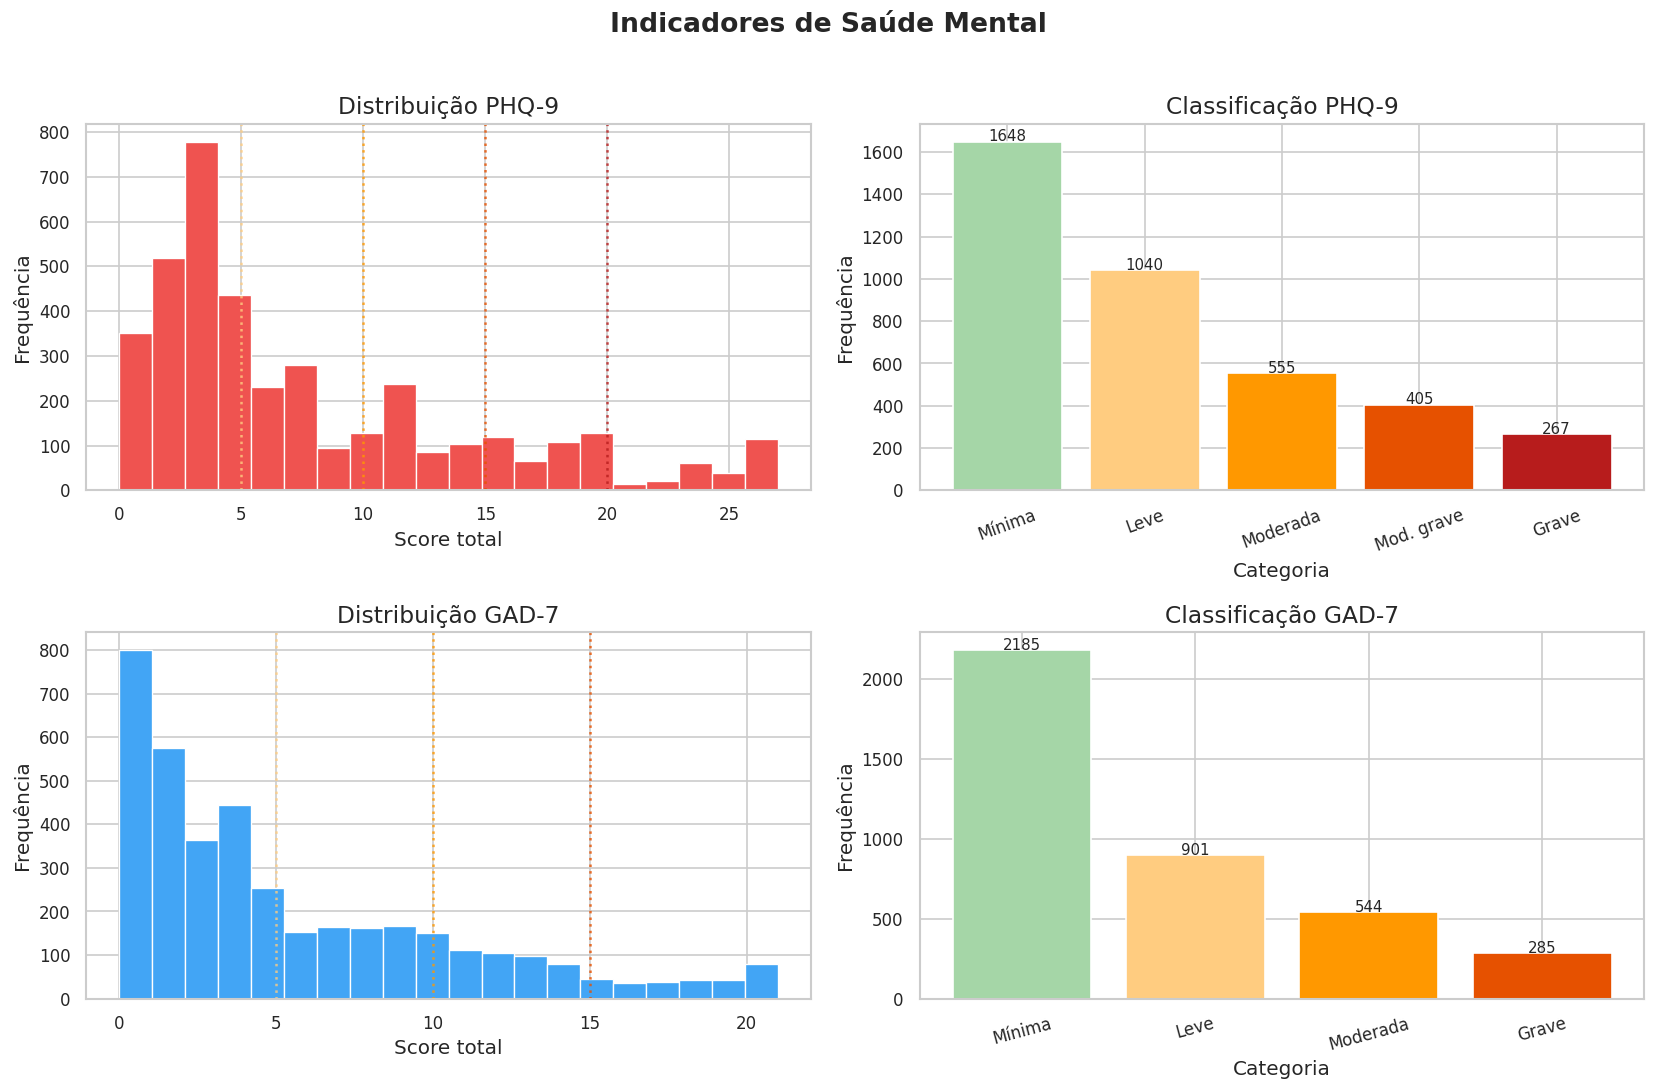

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Distribuição PHQ-9
axes[0, 0].hist(df['phq9_total'], bins=20, color='#EF5350',
                edgecolor='white', linewidth=0.8)
axes[0, 0].set_title('Distribuição PHQ-9')
axes[0, 0].set_xlabel('Score total')
axes[0, 0].set_ylabel('Frequência')
for lim, cor in zip([5, 10, 15, 20], ['#FFCC80','#FF9800','#E65100','#B71C1C']):
    axes[0, 0].axvline(lim, color=cor, linestyle=':', alpha=0.8)

# 2. Classificação PHQ-9
ordem_phq = labels_phq9
phq_counts = df['phq9_classe'].value_counts().reindex(ordem_phq)
axes[0, 1].bar(phq_counts.index, phq_counts.values,
               color=['#A5D6A7','#FFCC80','#FF9800','#E65100','#B71C1C'])
axes[0, 1].set_title('Classificação PHQ-9')
axes[0, 1].set_xlabel('Categoria')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].tick_params(axis='x', rotation=20)
for bar, val in zip(axes[0,1].patches, phq_counts.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                    str(int(val)), ha='center', fontsize=9)

# 3. Distribuição GAD-7
axes[1, 0].hist(df['gad7_total'], bins=20, color='#42A5F5',
                edgecolor='white', linewidth=0.8)
axes[1, 0].set_title('Distribuição GAD-7')
axes[1, 0].set_xlabel('Score total')
axes[1, 0].set_ylabel('Frequência')
for lim, cor in zip([5, 10, 15], ['#FFCC80','#FF9800','#E65100']):
    axes[1, 0].axvline(lim, color=cor, linestyle=':', alpha=0.8)

# 4. Classificação GAD-7
ordem_gad = labels_gad7
gad_counts = df['gad7_classe'].value_counts().reindex(ordem_gad)
axes[1, 1].bar(gad_counts.index, gad_counts.values,
               color=['#A5D6A7','#FFCC80','#FF9800','#E65100'])
axes[1, 1].set_title('Classificação GAD-7')
axes[1, 1].set_xlabel('Categoria')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].tick_params(axis='x', rotation=15)
for bar, val in zip(axes[1,1].patches, gad_counts.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                    str(int(val)), ha='center', fontsize=9)

fig.suptitle('Indicadores de Saúde Mental', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Análise Bivariada e Correlações




### 5.1 Matriz de Correlações



Calcula-se a matriz de correlações de _Spearman_ (adequada a distribuições não normais) entre as variáveis numéricas mais relevantes para a saúde mental.

#### **O que é a Matriz de Correlações de Spearman?**

A **matriz de correlações de Spearman** é uma tabela que mostra simultaneamente as correlações entre **todos os pares de variáveis** do conjunto analisado. Cada célula contém o coeficiente r_s entre a variável da linha e a variável da coluna.

O **coeficiente de Spearman** mede a **força e a direção** da relação entre duas variáveis,
numa escala de −1 a +1, sem assumir que os dados seguem uma distribuição normal
(ao contrário da correlação de Pearson). Por isso é mais adequado para variáveis como
os _scores_ do PHQ-9 e GAD-7.

| Valor de r_s | Interpretação |
|---|---|
| 0,90 a 1,00 | Correlação muito forte |
| 0,70 a 0,89 | Correlação forte |
| 0,40 a 0,69 | Correlação moderada |
| 0,20 a 0,39 | Correlação fraca |
| 0,00 a 0,19 | Correlação muito fraca ou inexistente |

Os valores negativos seguem a mesma escala mas em sentido inverso.

A diagonal principal teria sempre o valor 1,00 (cada variável correlaciona-se perfeitamente
consigo própria), pelo que é omitida. Mostra-se apenas o **triângulo inferior** para evitar
redundância, uma vez que a correlação entre A e B é igual à correlação entre B e A.

As cores ajudam a leitura: **vermelho** indica correlação positiva, **azul** indica correlação
negativa, e branco indica ausência de correlação.

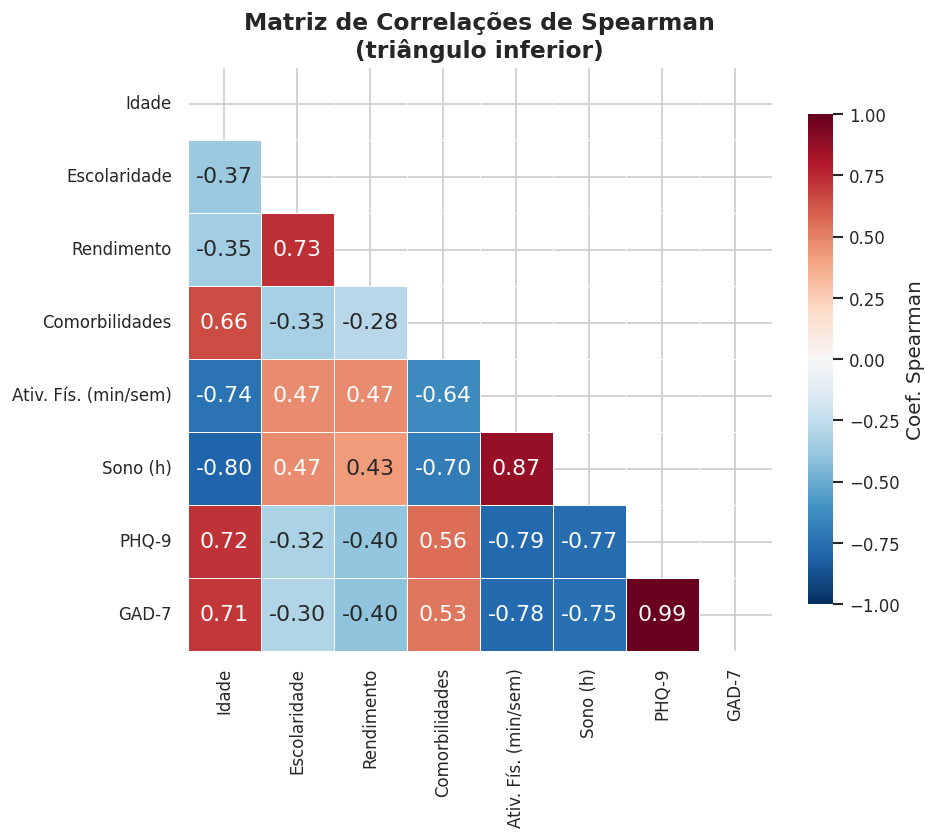


Correlações mais fortes com PHQ-9 (|r| > 0,25):
GAD-7                   0.989526
Ativ. Fís. (min/sem)   -0.786143
Sono (h)               -0.768050
Idade                   0.721583
Comorbilidades          0.562444
Rendimento             -0.396146
Escolaridade           -0.315735

Correlações mais fortes com GAD-7 (|r| > 0,25):
PHQ-9                   0.989526
Ativ. Fís. (min/sem)   -0.778593
Sono (h)               -0.753138
Idade                   0.707442
Comorbilidades          0.533130
Rendimento             -0.402351
Escolaridade           -0.302685


In [18]:
vars_corr = [
    'age', 'education_years', 'monthly_income', 'comorbidities_count',
    'physical_activity_total_minutes_week', 'sleep_hours',
    'phq9_total', 'gad7_total'
]

labels_corr = [
    'Idade', 'Escolaridade', 'Rendimento', 'Comorbilidades',
    'Ativ. Fís. (min/sem)', 'Sono (h)', 'PHQ-9', 'GAD-7'
]

corr_matrix = df[vars_corr].corr(method='spearman')
corr_matrix.columns = labels_corr
corr_matrix.index   = labels_corr

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Coef. Spearman'},
    ax=ax
)
ax.set_title('Matriz de Correlações de Spearman\n(triângulo inferior)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelações mais fortes com PHQ-9 (|r| > 0,25):")
c9 = corr_matrix['PHQ-9'].drop('PHQ-9').sort_values(key=abs, ascending=False)
print(c9[abs(c9) > 0.25].to_string())

print("\nCorrelações mais fortes com GAD-7 (|r| > 0,25):")
cg = corr_matrix['GAD-7'].drop('GAD-7').sort_values(key=abs, ascending=False)
print(cg[abs(cg) > 0.25].to_string())


> **Nota:** A correlação de Spearman entre PHQ-9 e GAD-7 é de r_s = 0,99, um valor
> praticamente perfeito que não é realista em dados clínicos reais. Esta ocorrência
> é expectável dado que o _dataset_ utilizado é de natureza **sintética**, os dados
> foram gerados artificialmente, o que tende a produzir relações entre variáveis
> excessivamente fortes e lineares, não refletindo a variabilidade e complexidade
> inerentes a amostras reais de população idosa.

### 5.2 Saúde Mental por Género

Compara-se a distribuição dos _scores_ PHQ-9 e GAD-7.
entre homens e mulheres, utilizando o **teste de Mann-Whitney U**.

#### **O que é o teste de Mann-Whitney U?**

O **teste de Mann-Whitney U** é um teste estatístico não paramétrico utilizado para comparar
dois grupos independentes. Ao contrário do teste t de Student, **não assume que os dados seguem
uma distribuição normal**, sendo por isso mais adequado para variáveis como os _scores_ do PHQ-9
e GAD-7, que são contagens discretas com distribuições tipicamente assimétricas.

O teste funciona em três passos:

1. **Ordenação conjunta** — todos os valores dos dois grupos são misturados e ordenados do menor
   para o maior, atribuindo um _rank_ (posição) a cada observação.
2. **Soma dos _ranks_** — somam-se os _ranks_ de cada grupo separadamente.
3. **Teste de hipótese** — avalia-se se a diferença nas somas de _ranks_ é maior do que seria
   esperado por acaso, assumindo que os dois grupos são iguais (hipótese nula).

O **valor p** resultante indica a probabilidade de se observar uma diferença tão grande (ou maior)
por mero acaso. Por convenção:

| Símbolo | Limiar | Interpretação |
|---|---|---|
| `***` | p < 0,001 | Diferença altamente significativa |
| `**`  | p < 0,01  | Diferença muito significativa |
| `*`   | p < 0,05  | Diferença significativa |
| `n.s.` | p ≥ 0,05 | Diferença não significativa (pode ser acaso) |

> **Nota importante:** o teste confirma *se* existe diferença, mas não indica *qual* grupo
> tem valores mais elevados — para isso, comparam-se as medianas em conjunto com os _boxplots_.


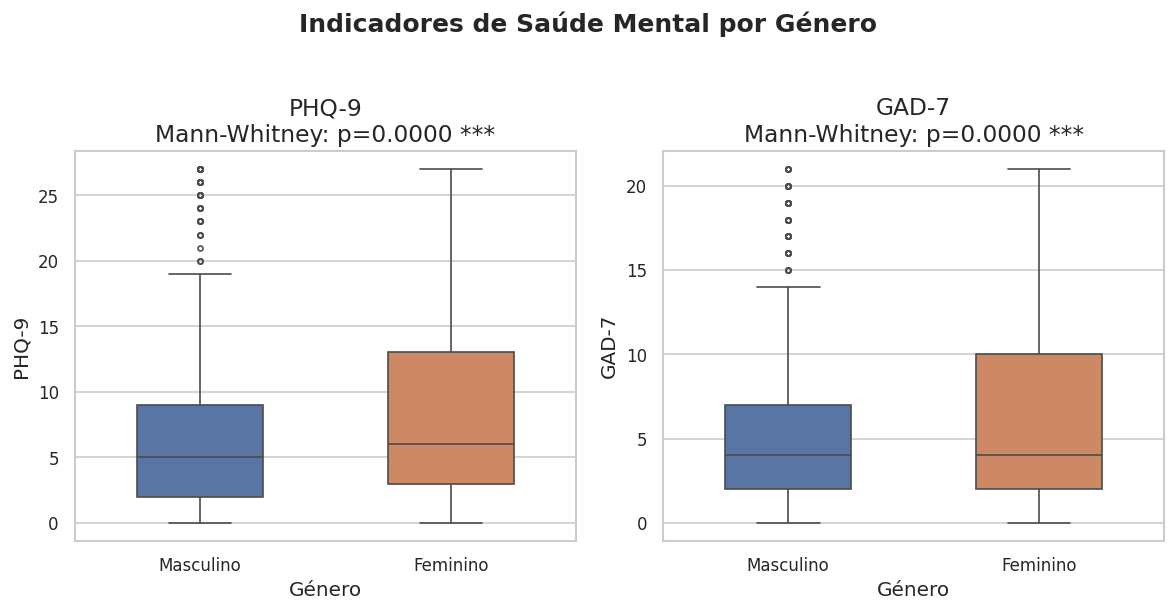

In [19]:
vars_sm  = ['phq9_total', 'gad7_total']
titulos  = ['PHQ-9', 'GAD-7']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, (var, titulo) in enumerate(zip(vars_sm, titulos)):
    sns.boxplot(data=df, x='genero_cat', y=var, palette=PALETA_GENERO, ax=axes[i],
                width=0.5, flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5})

    g1 = df.loc[df['genero_cat'] == 'Masculino', var].dropna()
    g2 = df.loc[df['genero_cat'] == 'Feminino',  var].dropna()
    stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
    sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'

    axes[i].set_title(f'{titulo}\nMann-Whitney: p={p:.4f} {sig}')
    axes[i].set_xlabel('Género')
    axes[i].set_ylabel(titulo)

fig.suptitle('Indicadores de Saúde Mental por Género',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [20]:
# ── Medianas por género para interpretar a direção da diferença ───────────
print("Medianas por género:")
print(df.groupby('genero_cat')[vars_sm].median().round(2))


Medianas por género:
            phq9_total  gad7_total
genero_cat                        
Feminino           6.0         4.0
Masculino          5.0         4.0


#### **Interpretação dos resultados — Saúde Mental por Género**

Os dois testes de Mann-Whitney U revelaram diferenças **estatisticamente significativas**
(p < 0,001) entre homens e mulheres em ambos os indicadores de saúde mental analisados.

A análise das medianas confirma a **direção** dessas diferenças:

- **PHQ-9:** as participantes do sexo feminino apresentaram uma mediana de **6,0** pontos,
  face a **5,0** nos homens — ambos dentro da categoria de sintomatologia leve, embora
  as mulheres apresentem valores consistentemente superiores.
- **GAD-7:** a mediana foi de **4,0** em ambos os géneros, situando-se no limiar entre
  ansiedade mínima e leve, sem diferença na mediana mas com distribuição distinta
  visível nos boxplots.

Apesar das diferenças de magnitude serem mais modestas do que em datasets clínicos reais, o que é expectável dado o caráter sintético dos dados, a significância estatística
mantém-se, sugerindo que o género é uma variável relevante na distribuição dos indicadores
de saúde mental nesta amostra.

### 5.3 Saúde Mental por Situação Habitacional

Analisa-se se a situação habitacional influencia os indicadores de saúde mental,
com recurso ao **teste de Kruskal-Wallis** (comparação de múltiplos grupos independentes).

#### **O que é o teste de Kruskal-Wallis?**

O **teste de Kruskal-Wallis** é a extensão não paramétrica da ANOVA de um fator, permitindo comparar
**três ou mais grupos independentes** sem assumir normalidade. Tal como o Mann-Whitney U, baseia-se
na ordenação (_ranking_) dos dados, mas generaliza o processo para múltiplos grupos.

A lógica é semelhante: se os grupos forem realmente iguais, os _ranks_ deverão distribuir-se
de forma semelhante entre eles. Uma concentração de _ranks_ elevados num determinado grupo produz
uma estatística H grande e, consequentemente, um valor p pequeno.

A hipótese nula é: *"todos os grupos têm a mesma distribuição"*. Um p < 0,05 indica que
**pelo menos um grupo difere** dos restantes, mas o teste não diz qual.

> **Diferença-chave face ao Mann-Whitney:** o Mann-Whitney compara **2 grupos**; o Kruskal-Wallis
> compara **3 ou mais grupos**. Neste caso, a situação habitacional tem 4 categorias
> (sozinho/a, com parceiro/a, com família, instituição), pelo que se usa o Kruskal-Wallis.


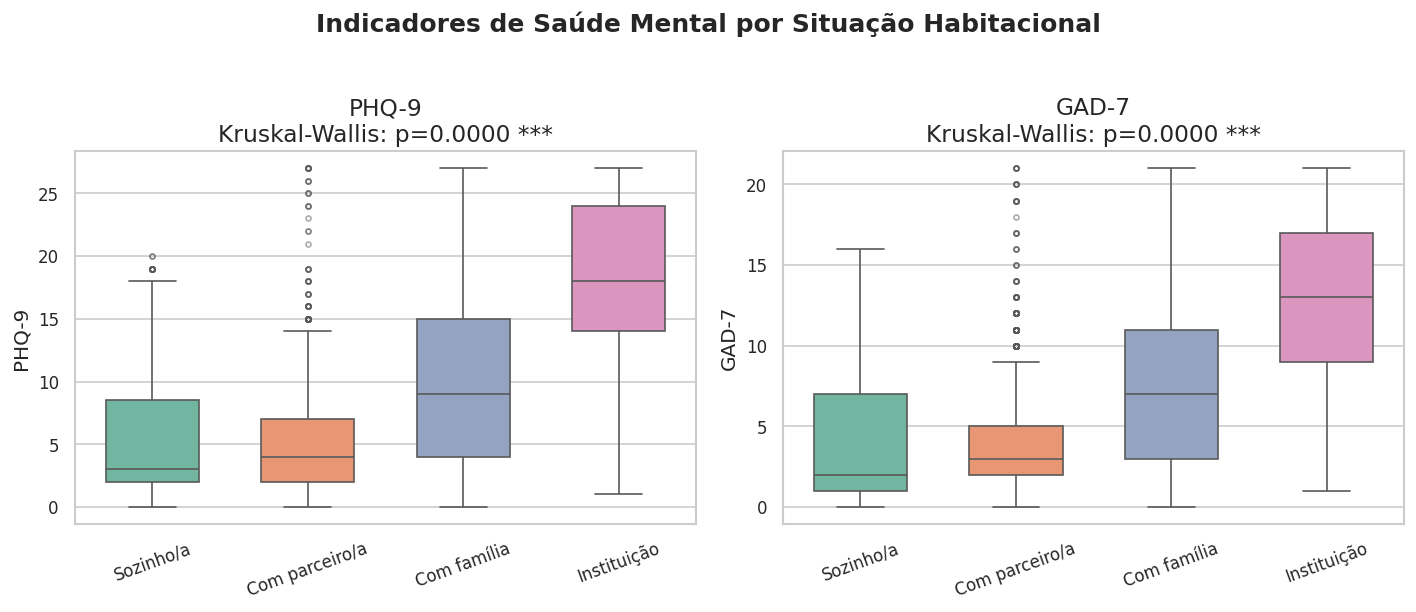

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (var, titulo) in enumerate(zip(vars_sm, titulos)):
    ordem_hab = df.groupby('habitacao_cat')[var].median().sort_values().index.tolist()
    sns.boxplot(data=df, x='habitacao_cat', y=var, order=ordem_hab,
                palette='Set2', ax=axes[i], width=0.6,
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5})

    grupos = [df.loc[df['habitacao_cat'] == g, var].dropna()
              for g in df['habitacao_cat'].unique()]
    stat, p = kruskal(*grupos)
    sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'

    axes[i].set_title(f'{titulo}\nKruskal-Wallis: p={p:.4f} {sig}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(titulo)
    axes[i].tick_params(axis='x', rotation=20)

fig.suptitle('Indicadores de Saúde Mental por Situação Habitacional',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [22]:
# ── Medianas por situação habitacional para interpretar a direção ─────────
print("Medianas por situação habitacional:")
print(df.groupby('habitacao_cat')[vars_sm].median().round(2).sort_values('phq9_total'))


Medianas por situação habitacional:
                phq9_total  gad7_total
habitacao_cat                         
Sozinho/a              3.0         2.0
Com parceiro/a         4.0         3.0
Com família            9.0         7.0
Instituição           18.0        13.0


#### **Interpretação dos resultados — Saúde Mental por Situação Habitacional**

Os dois testes de Kruskal-Wallis demonstraram diferenças **altamente significativas** (p < 0,001)
entre os quatro contextos habitacionais em ambos os indicadores de saúde mental.

A análise das medianas revela um **gradiente claro de risco**:

| Situação Habitacional | PHQ-9 (mediana) | GAD-7 (mediana) |
|---|---|---|
| Sozinho/a | 3,0 | 2,0 |
| Com parceiro/a | 4,0 | 3,0 |
| Com família | 9,0 | 7,0 |
| Instituição | 18,0 | 13,0 |

Os participantes que vivem **sozinhos/as** e **com parceiro/a** apresentam os valores mais
baixos de sintomatologia depressiva e ansiosa, com medianas dentro da categoria sem depressão
e ansiedade mínima, respetivamente. Os que vivem **com família** situam-se num nível
intermédio, enquanto os idosos **institucionalizados** apresentam valores substancialmente
mais elevados, PHQ-9 mediana de 18 (moderadamente grave) e GAD-7 de 13 (moderada),
refletindo possivelmente a maior fragilidade desta população e o impacto da perda de
autonomia e do ambiente familiar.

> **Nota metodológica:** embora o Kruskal-Wallis confirme que *pelo menos um* grupo difere,
> a ordenação consistente das medianas em ambos os indicadores reforça a robustez das
> diferenças observadas entre os grupos.

### 5.4 Atividade Física e Saúde Mental

Investiga-se a relação entre o cumprimento das recomendações de atividade física da OMS
e os indicadores de saúde mental.


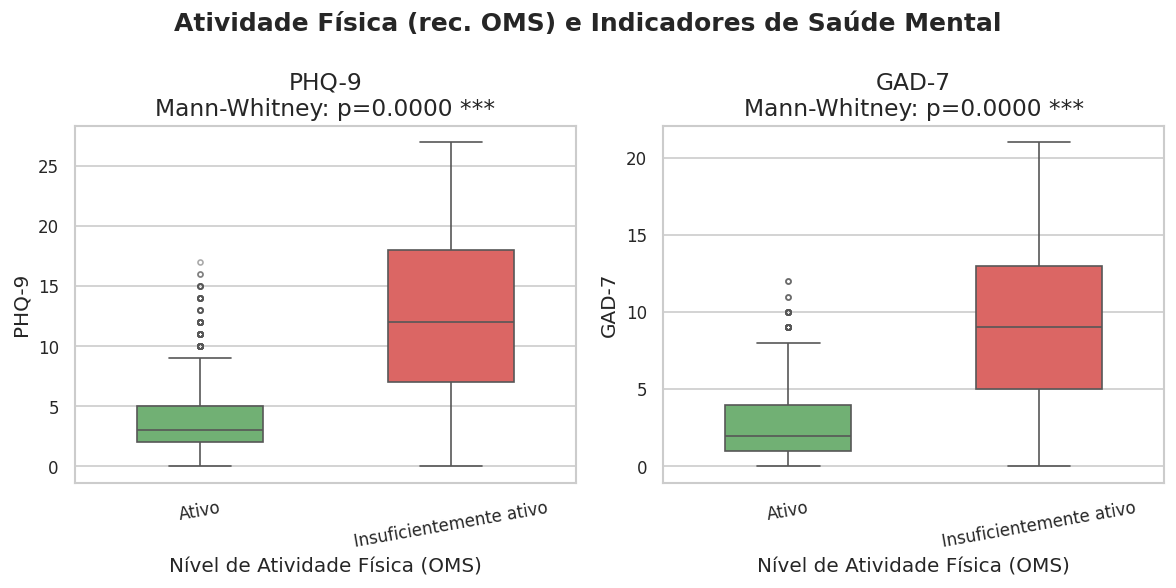

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, (var, titulo) in enumerate(zip(vars_sm, titulos)):
    sns.boxplot(data=df, x='activo_fisicamente', y=var,
                palette={'Ativo': '#66BB6A', 'Insuficientemente ativo': '#EF5350'},
                ax=axes[i], width=0.5,
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5})

    g1 = df.loc[df['activo_fisicamente'] == 'Ativo',                   var].dropna()
    g2 = df.loc[df['activo_fisicamente'] == 'Insuficientemente ativo',  var].dropna()
    stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
    sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'

    axes[i].set_title(f'{titulo}\nMann-Whitney: p={p:.4f} {sig}')
    axes[i].set_xlabel('Nível de Atividade Física (OMS)')
    axes[i].set_ylabel(titulo)
    axes[i].tick_params(axis='x', rotation=10)

fig.suptitle('Atividade Física (rec. OMS) e Indicadores de Saúde Mental',
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [24]:
print("Medianas por nível de atividade física:")
print(df.groupby('activo_fisicamente')[vars_sm].median().round(2))


Medianas por nível de atividade física:
                         phq9_total  gad7_total
activo_fisicamente                             
Ativo                           3.0         2.0
Insuficientemente ativo        12.0         9.0


#### Interpretação dos resultados — Atividade Física e Saúde Mental

Os **testes de Mann-Whitney U** revelaram diferenças **altamente significativas** (p < 0,001)
entre participantes ativos e insuficientemente ativos em ambos os indicadores.

A magnitude das diferenças é notável:

- **PHQ-9:** mediana de **3,0** nos ativos vs. **12,0** nos insuficientemente ativos — uma
  diferença de 9 pontos que representa a distinção entre ausência de depressão e depressão
  moderada.
- **GAD-7:** mediana de **2,0** vs. **9,0** — os participantes ativos situam-se na categoria
  de ansiedade mínima, enquanto os insuficientemente ativos atingem o limiar da ansiedade leve
  a moderada.

Estes resultados sublinham a relevância clínica e de saúde pública da promoção da atividade
física regular em idosos, consistente com a ampla evidência sobre os seus benefícios
para a saúde mental.

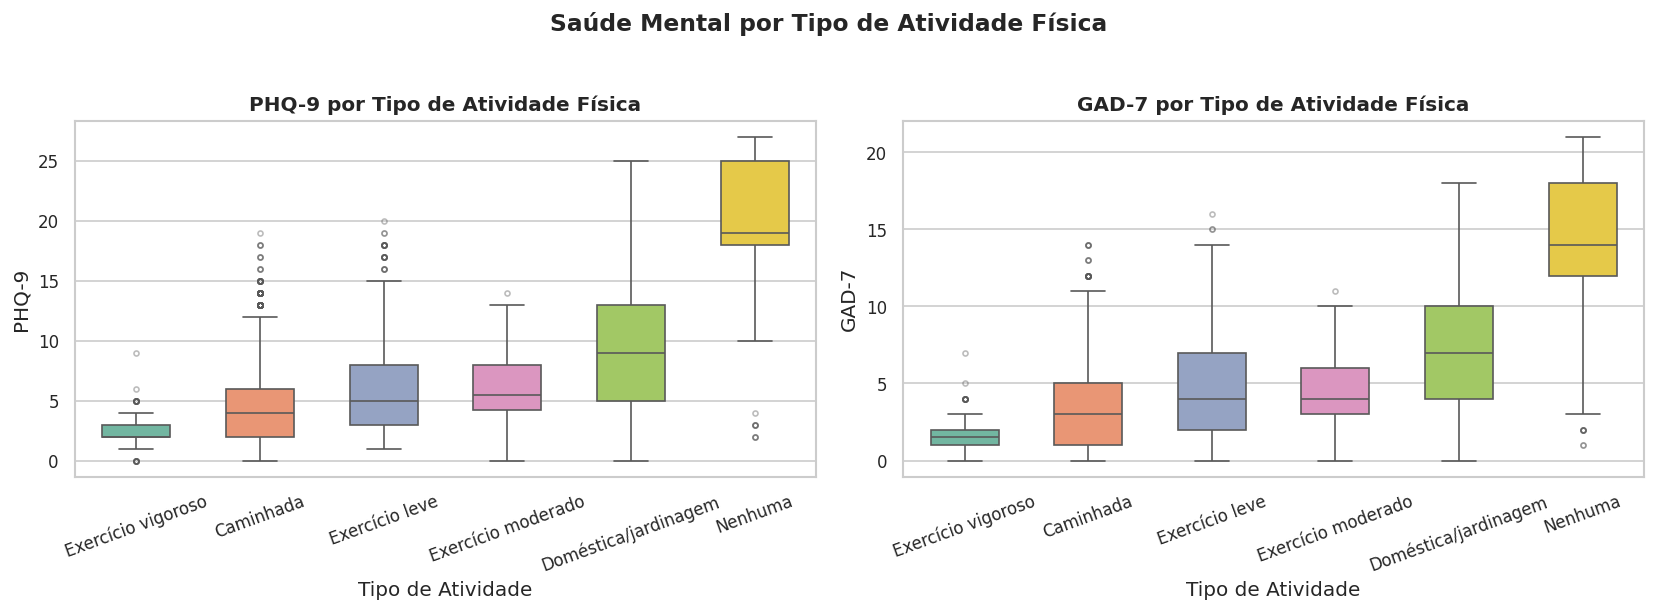

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ordem_tipo = (df.groupby('tipo_ativ_cat')['phq9_total']
                .median().sort_values().index.tolist())

for ax, var, titulo in zip(
    axes,
    ['phq9_total', 'gad7_total'],
    ['PHQ-9', 'GAD-7']
):
    sns.boxplot(data=df, x='tipo_ativ_cat', y=var, order=ordem_tipo,
                palette='Set2', ax=ax, width=0.55,
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4})
    ax.set_title(f'{titulo} por Tipo de Atividade Física', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tipo de Atividade')
    ax.set_ylabel(titulo)
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('Saúde Mental por Tipo de Atividade Física',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

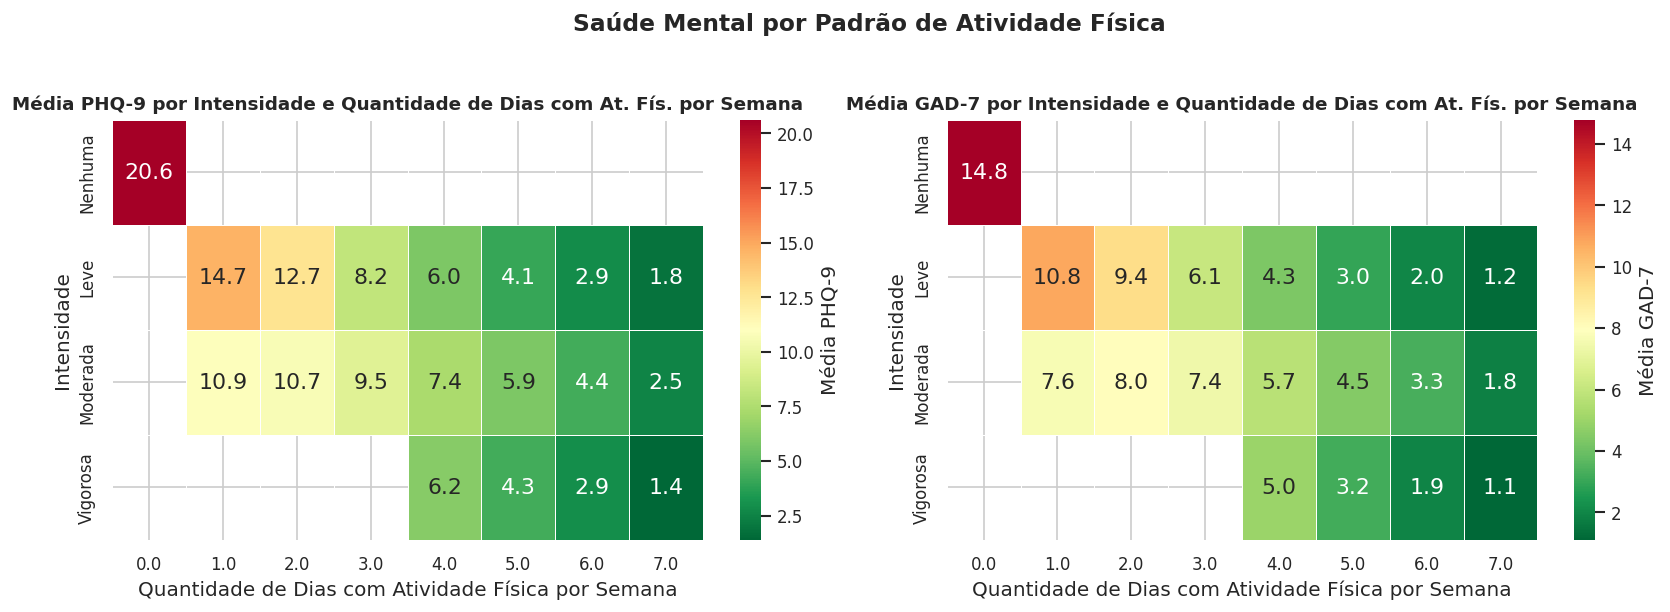

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var, titulo in zip(
    axes,
    ['phq9_total', 'gad7_total'],
    ['PHQ-9', 'GAD-7']
):
    pivot = df.pivot_table(
        values=var,
        index='intensidade_cat',
        columns='physical_activity_days_per_week',
        aggfunc='mean',
        observed=True
    ).reindex(['Nenhuma', 'Leve', 'Moderada', 'Vigorosa'])

    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
                linewidths=0.5, ax=ax,
                cbar_kws={'label': f'Média {titulo}'})
    ax.set_title(f'Média {titulo} por Intensidade e Quantidade de Dias com At. Fís. por Semana',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Quantidade de Dias com Atividade Física por Semana')
    ax.set_ylabel('Intensidade')

fig.suptitle('Saúde Mental por Padrão de Atividade Física',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

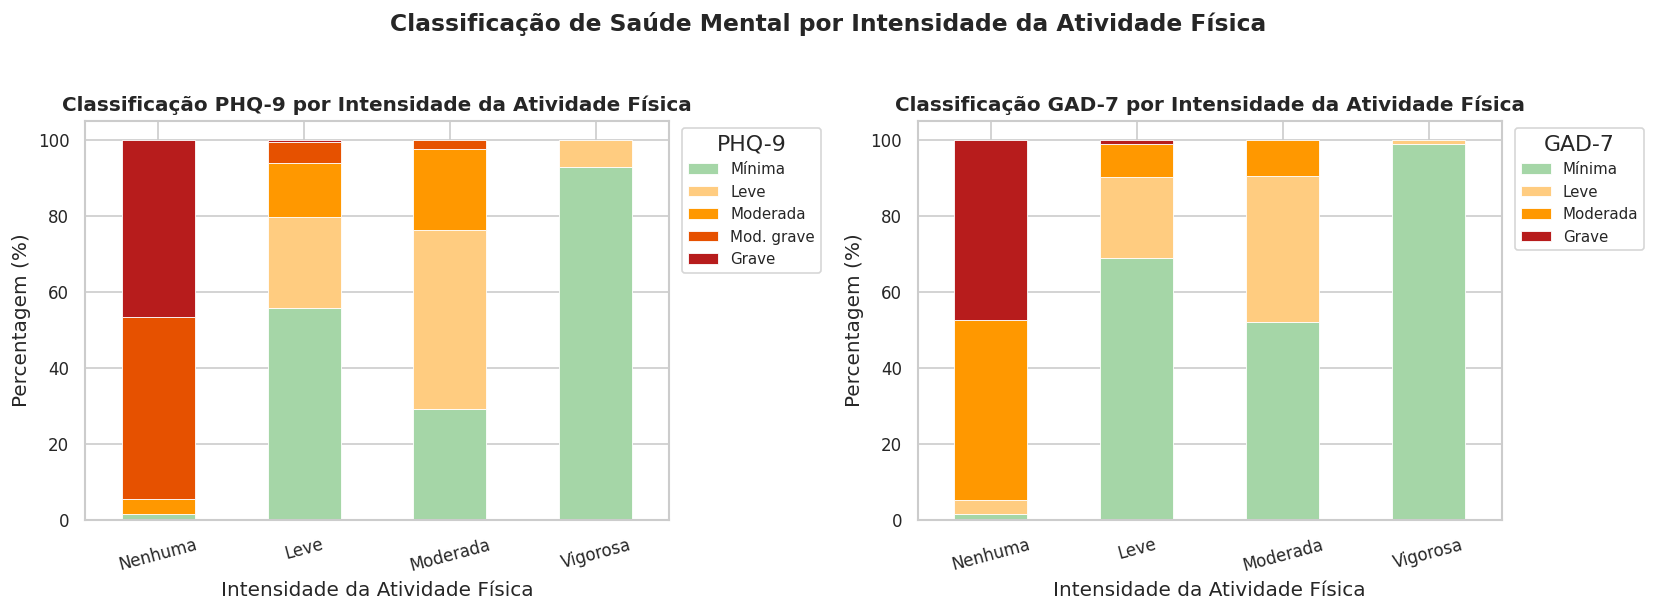

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var_classe, titulo, cores in zip(
    axes,
    ['phq9_classe', 'gad7_classe'],
    ['PHQ-9', 'GAD-7'],
    [['#A5D6A7','#FFCC80','#FF9800','#E65100','#B71C1C'],
     ['#A5D6A7','#FFCC80','#FF9800','#B71C1C']]
):
    pivot = (df.groupby(['intensidade_cat', var_classe], observed=True)
               .size().unstack(fill_value=0))
    pivot = pivot.div(pivot.sum(axis=1), axis=0) * 100
    pivot.reindex(['Nenhuma','Leve','Moderada','Vigorosa']).plot(
        kind='bar', stacked=True, ax=ax, color=cores,
        edgecolor='white', linewidth=0.5
    )
    ax.set_title(f'Classificação {titulo} por Intensidade da Atividade Física', fontsize=12, fontweight='bold')
    ax.set_xlabel('Intensidade da Atividade Física')
    ax.set_ylabel('Percentagem (%)')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title=titulo, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

fig.suptitle('Classificação de Saúde Mental por Intensidade da Atividade Física',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

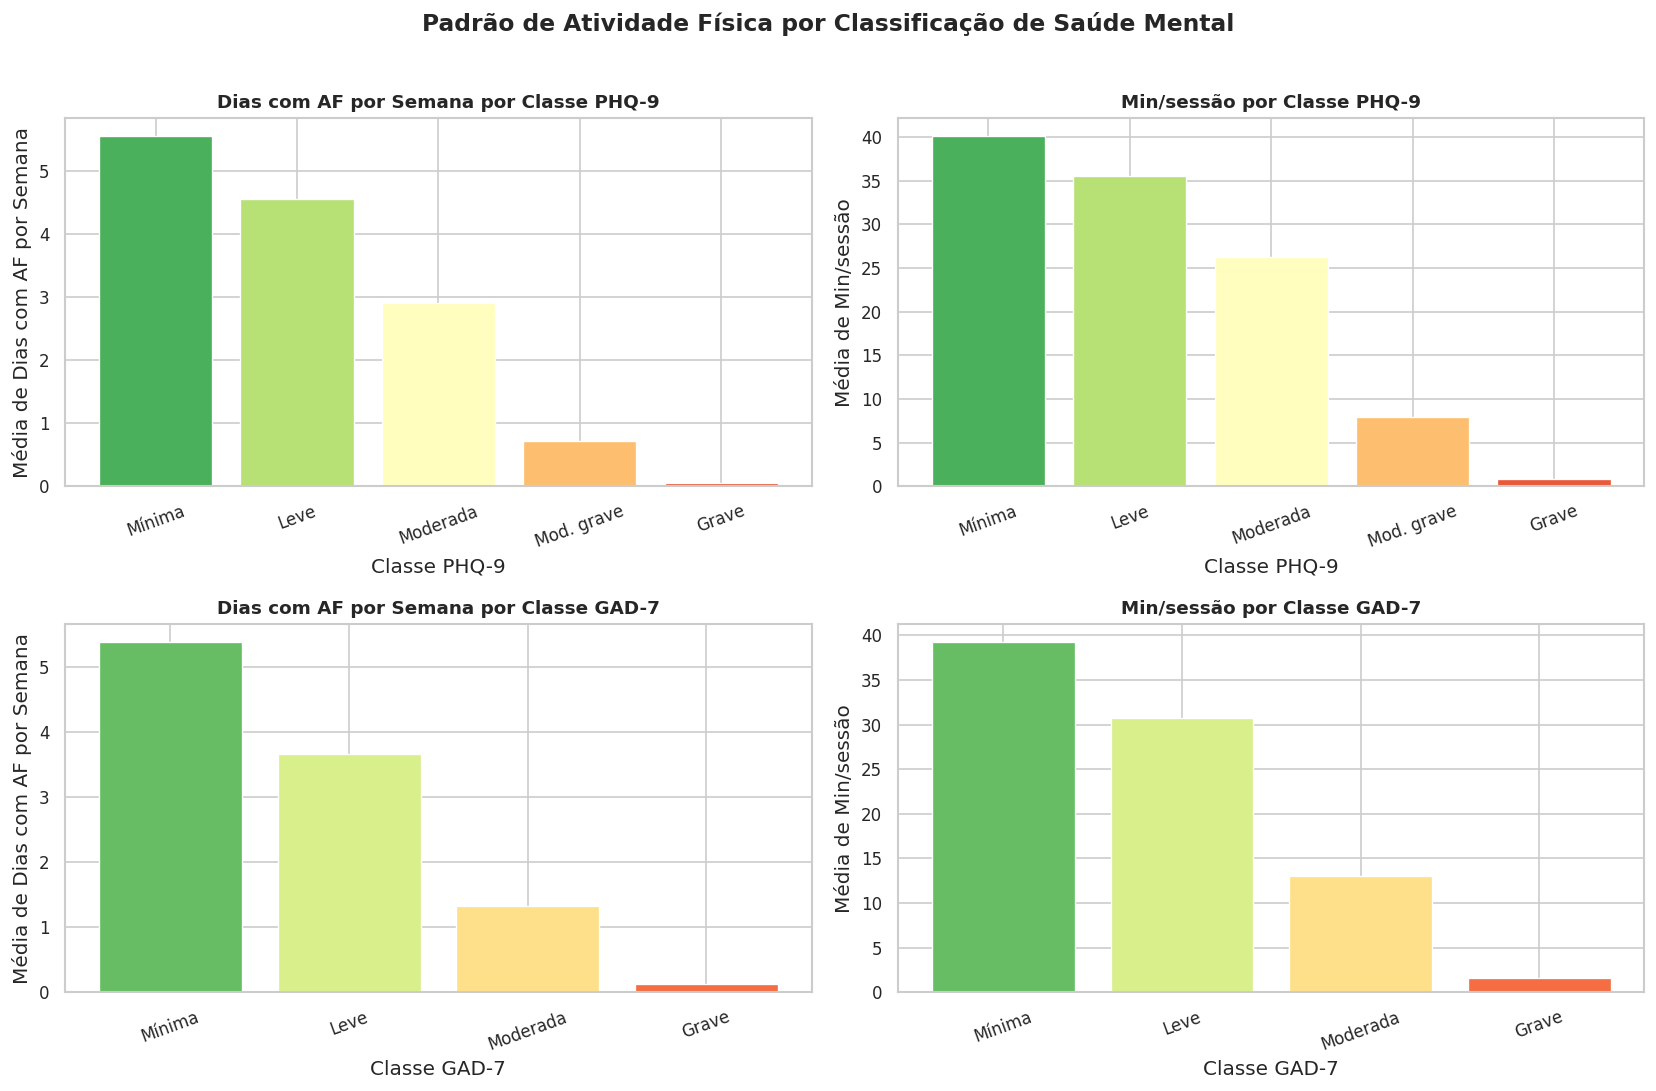

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

pares = [
    ('phq9_classe', 'physical_activity_days_per_week',       labels_phq9, 'PHQ-9',  'Dias com AF por Semana'),
    ('phq9_classe', 'physical_activity_minutes_per_session', labels_phq9, 'PHQ-9',  'Min/sessão'),
    ('gad7_classe', 'physical_activity_days_per_week',       labels_gad7, 'GAD-7',  'Dias com AF por Semana'),
    ('gad7_classe', 'physical_activity_minutes_per_session', labels_gad7, 'GAD-7',  'Min/sessão'),
]

for ax, (classe, var_af, ordem, lbl_classe, lbl_af) in zip(axes.flatten(), pares):
    dados = df.groupby(classe, observed=True)[var_af].mean().reindex(ordem)
    cores = sns.color_palette('RdYlGn_r', len(ordem))
    ax.bar(dados.index, dados.values, color=cores, edgecolor='white', linewidth=0.8)
    ax.set_title(f'{lbl_af} por Classe {lbl_classe}', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'Classe {lbl_classe}')
    ax.set_ylabel(f'Média de {lbl_af}')
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('Padrão de Atividade Física por Classificação de Saúde Mental',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.5 Sono e Saúde Mental




Analisa-se a relação entre as horas de sono e os indicadores
de saúde mental através de gráficos de dispersão com linha de tendência.

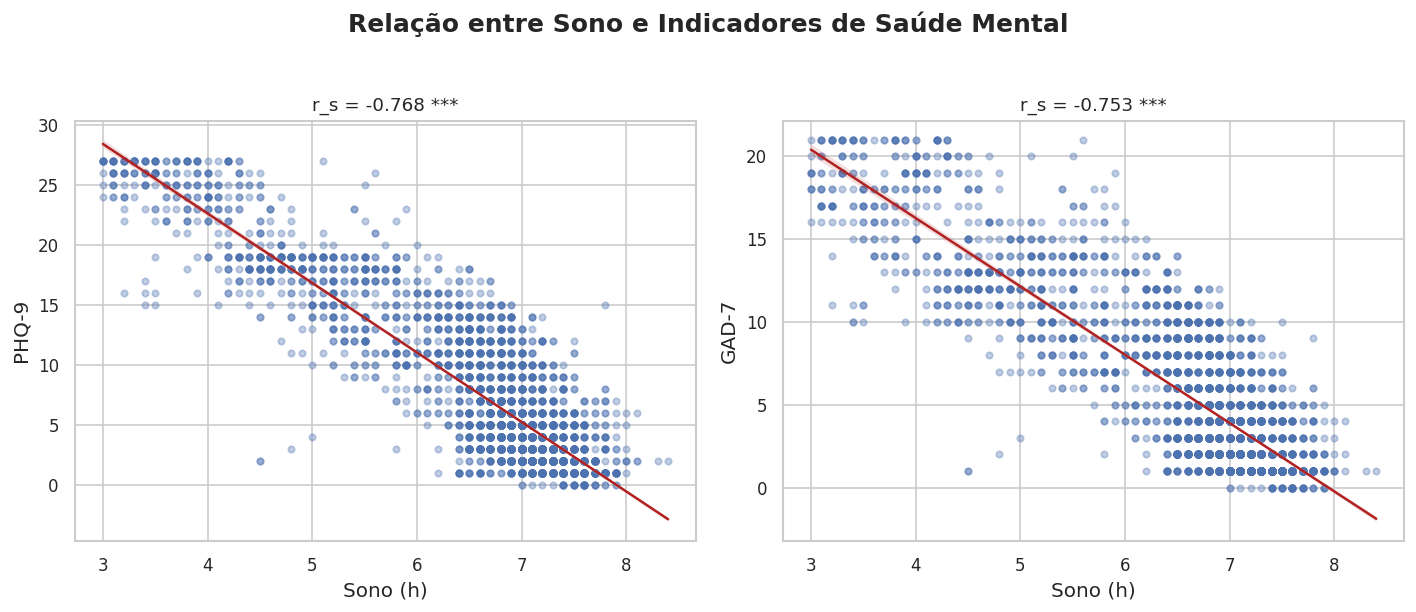

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pares = [
    ('sleep_hours', 'phq9_total', 'Sono (h)', 'PHQ-9'),
    ('sleep_hours', 'gad7_total', 'Sono (h)', 'GAD-7'),
]

for ax, (x, y, xl, yl) in zip(axes, pares):
    sub = df[[x, y]].dropna()
    sns.regplot(data=sub, x=x, y=y, ax=ax,
                scatter_kws={'alpha': 0.35, 's': 15, 'color': '#4C72B0'},
                line_kws={'color': 'firebrick', 'linewidth': 1.5})
    r, p = spearmanr(sub[x], sub[y])
    sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'
    ax.set_title(f'r_s = {r:.3f} {sig}', fontsize=11)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)

fig.suptitle('Relação entre Sono e Indicadores de Saúde Mental',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### **Interpretação dos gráficos de dispersão**

Cada gráfico mostra a relação entre duas variáveis através de um diagrama de dispersão
com uma linha de tendência ajustada. O valor **r_s** no título de cada gráfico é o
coeficiente de Spearman explicado na secção 5.1 — quanto mais próximo de +1 ou −1,
mais forte é a associação.

Nos gráficos desta secção destaca-se uma relação de grande magnitude:

- **Sono → PHQ-9** (r_s = −0,768 ***) — **relação negativa forte:**
  quanto mais horas de sono, menor a sintomatologia depressiva.
- **Sono → GAD-7** (r_s = −0,753 ***) — **relação negativa forte:**
  quanto mais horas de sono, menor a sintomatologia ansiosa.

A linha de tendência é descendente em ambos os gráficos, confirmando que participantes
com menos horas de sono tendem a apresentar scores mais elevados nos dois indicadores.

> **Atenção:** correlação não implica causalidade. A relação entre sono e saúde mental
> pode ser bidirecional — a depressão e a ansiedade perturbam o sono, e o sono
> insuficiente agrava estes sintomas. Para estabelecer causalidade seria necessário
> um estudo longitudinal.

---
## 6. Visualizações Avançadas




### 6.1 Perfil de Saúde Mental por Grupo Etário e Atividade Física

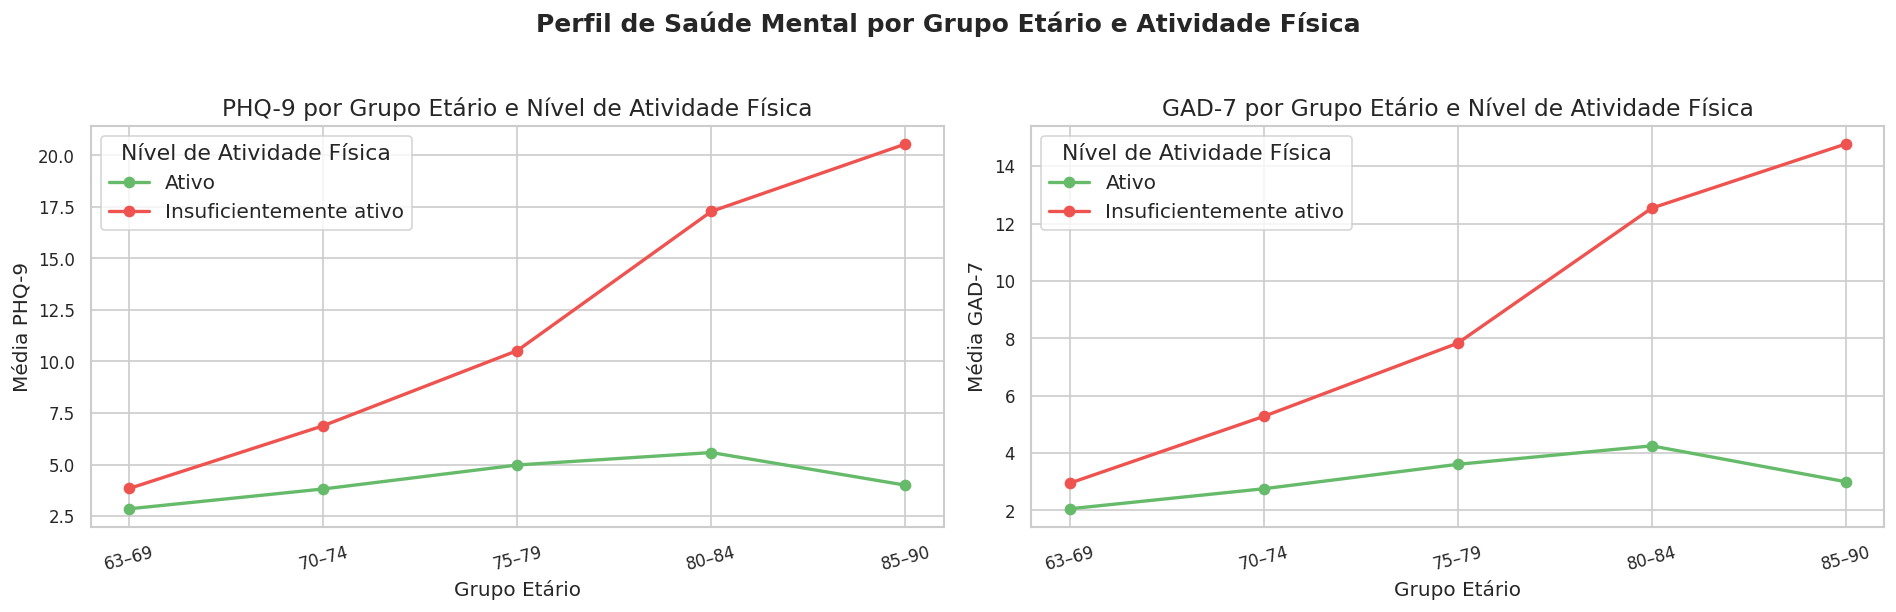

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, (var, titulo) in enumerate(zip(vars_sm, titulos)):
    dados_af = (df.groupby(['grupo_etario', 'activo_fisicamente'], observed=True)[var]
                .mean().reset_index())
    for nivel, cor in zip(['Ativo', 'Insuficientemente ativo'], ['#66BB6A', '#EF5350']):
        subset = dados_af[dados_af['activo_fisicamente'] == nivel]
        axes[i].plot(subset['grupo_etario'], subset[var],
                     marker='o', label=nivel, color=cor, linewidth=2, markersize=6)
    axes[i].set_title(f'{titulo} por Grupo Etário e Nível de Atividade Física')
    axes[i].set_xlabel('Grupo Etário')
    axes[i].set_ylabel(f'Média {titulo}')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].legend(title='Nível de Atividade Física')

fig.suptitle('Perfil de Saúde Mental por Grupo Etário e Atividade Física',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Distribuição de Indicadores de Saúde Mental por Estado Civil e Género


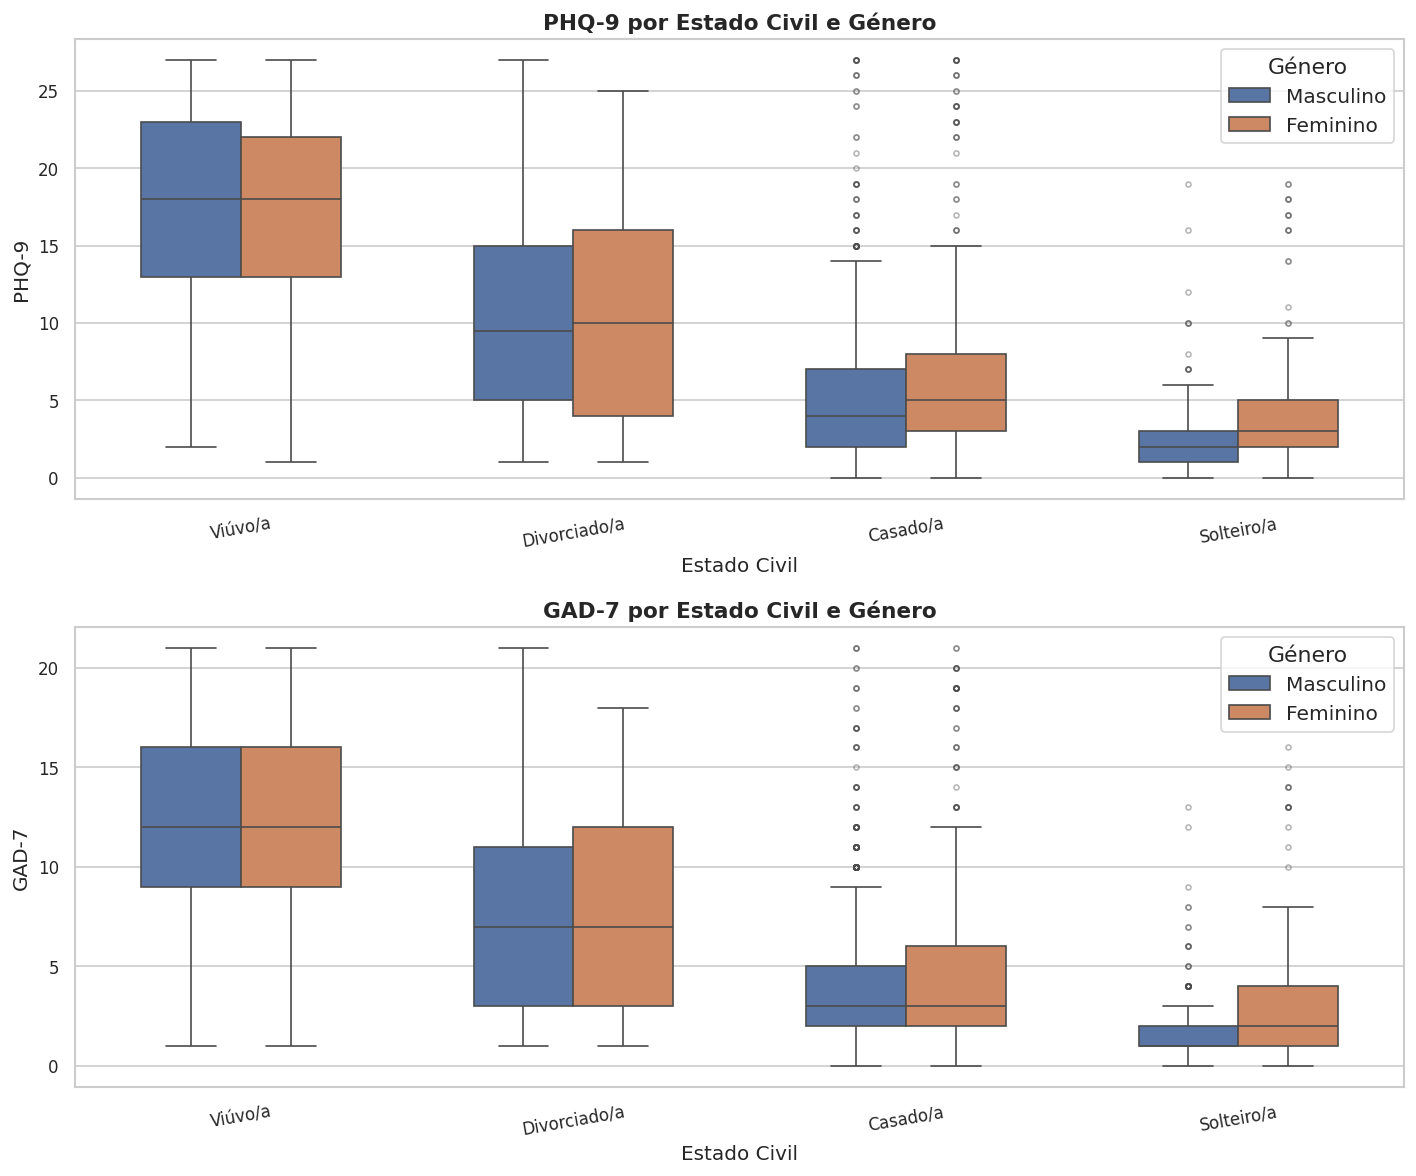

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for ax, var, titulo, cor in zip(
    axes,
    ['phq9_total', 'gad7_total'],
    ['PHQ-9', 'GAD-7'],
    ['#EF5350', '#42A5F5']
):
    ordem_ec = df.groupby('estado_civil_cat')[var].median().sort_values(ascending=False).index.tolist()
    sns.boxplot(data=df, x='estado_civil_cat', y=var,
                hue='genero_cat', order=ordem_ec,
                palette=PALETA_GENERO, width=0.6, ax=ax,
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4})
    ax.set_title(f'{titulo} por Estado Civil e Género', fontsize=13, fontweight='bold')
    ax.set_xlabel('Estado Civil')
    ax.set_ylabel(titulo)
    ax.tick_params(axis='x', rotation=10)
    ax.legend(title='Género')

plt.tight_layout()
plt.show()

### 6.3 Mapa de Calor — PHQ-9 e GAD-7 por Grupo Etário e Situação Habitacional


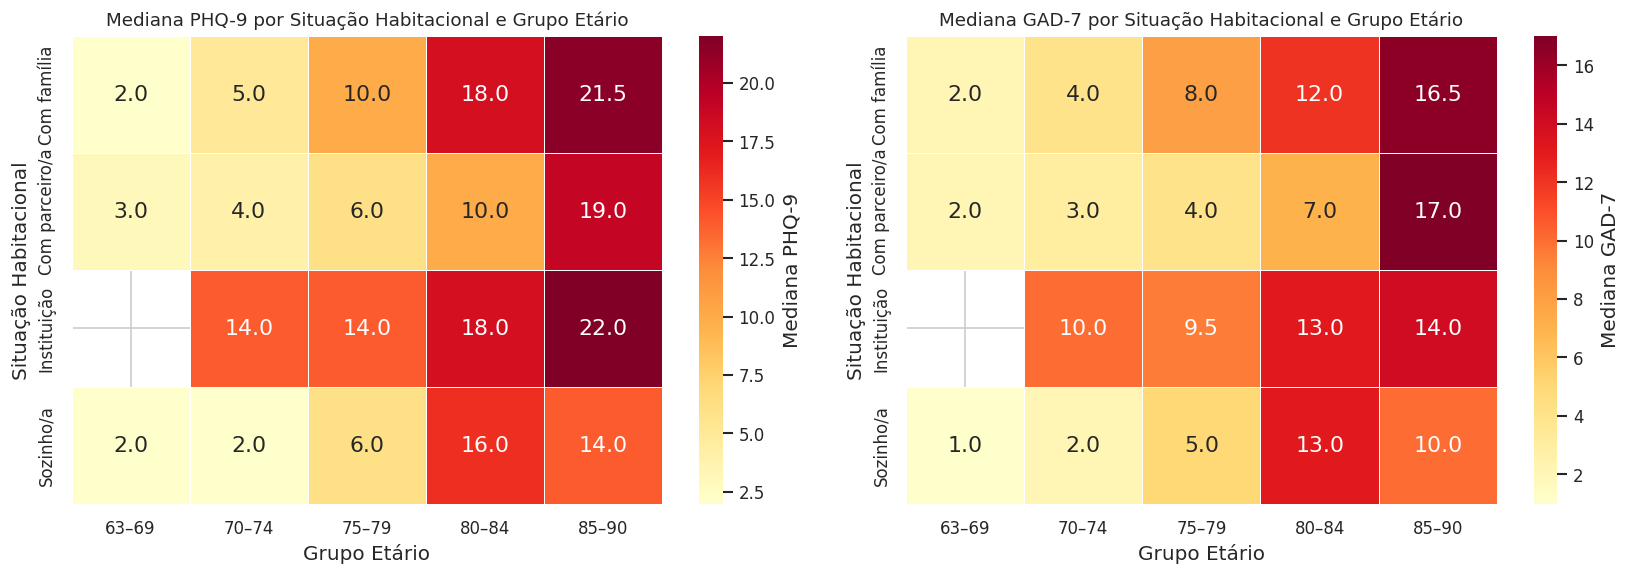

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var, titulo in zip(axes, ['phq9_total', 'gad7_total'], ['PHQ-9', 'GAD-7']):
    pivot = df.pivot_table(values=var, index='habitacao_cat',
                           columns='grupo_etario', aggfunc='median', observed=True)
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar_kws={'label': f'Mediana {titulo}'})
    ax.set_title(f'Mediana {titulo} por Situação Habitacional e Grupo Etário', fontsize=11)
    ax.set_xlabel('Grupo Etário')
    ax.set_ylabel('Situação Habitacional')

plt.tight_layout()
plt.show()

### 6.4 Associação entre Tipo de Atividade Física e Intensidade


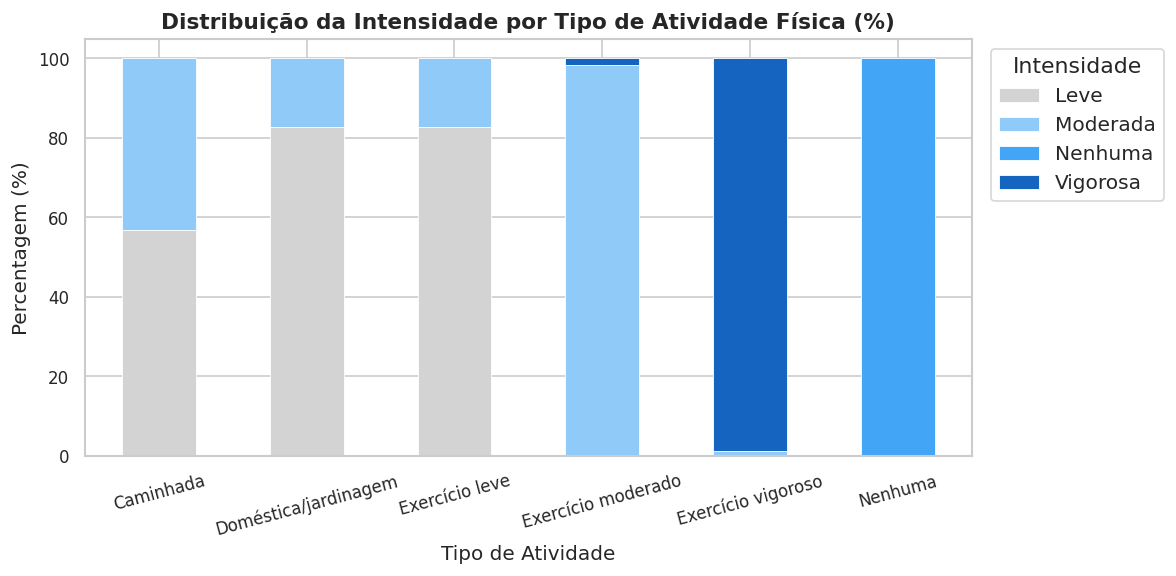

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
pivot_af = df.pivot_table(index='tipo_ativ_cat', columns='intensidade_cat',
                          values='participant_id', aggfunc='count', observed=True)
pivot_af = pivot_af.div(pivot_af.sum(axis=1), axis=0) * 100

pivot_af.plot(kind='bar', stacked=True, ax=ax,
              color=['#d3d3d3','#90CAF9','#42A5F5','#1565C0'],
              edgecolor='white', linewidth=0.5)
ax.set_title('Distribuição da Intensidade por Tipo de Atividade Física (%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Tipo de Atividade')
ax.set_ylabel('Percentagem (%)')
ax.legend(title='Intensidade', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


---
## 7. Conclusões

Com base na análise exploratória e inferencial realizada, destacam-se as seguintes conclusões:

### 7.1 Caracterização da Amostra

- A amostra inclui **3.915 idosos** (63–90 anos), com média de idade de 74,7 anos (DP = 5,3).
- O género feminino é ligeiramente predominante (52,6 %); a maioria dos participantes é
  casado/a (64,4 %) ou viúvo/a (17,9 %).
- A maioria vive com parceiro/a (62,9 %); 16,1 % em instituição e 11,5 % sozinho/a.

### 7.2 Atividade Física

- **55,8 %** dos participantes cumpre as recomendações da OMS (≥ 150 min/semana),
  com uma média de 154,5 min/semana.
- A caminhada é o tipo de atividade mais praticada (1.853 participantes),
  com intensidade predominantemente leve.

### 7.3 Saúde Mental

- A maioria dos participantes situa-se nas categorias sem depressão (1.648) e leve (1.040)
  no PHQ-9, embora 267 apresentem sintomatologia grave.
- No GAD-7, predomina a categoria mínima (2.185), com 285 participantes na categoria grave.
- A média do PHQ-9 é 7,8 (DP = 6,8) e do GAD-7 é 5,7 (DP = 5,0).

### 7.4 Principais Associações Identificadas

| Associação | Direção | Significância |
|---|---|---|
| Sono ↔ PHQ-9 | Negativa forte (r_s = −0,768) | p < 0,001 |
| Sono ↔ GAD-7 | Negativa forte (r_s = −0,753) | p < 0,001 |
| Atividade física (OMS) ↔ PHQ-9 / GAD-7 | Negativa (medianas: 3 vs. 12 / 2 vs. 9) | p < 0,001 |
| Situação habitacional ↔ saúde mental | Instituição = pior (PHQ-9=18); sozinho/a = melhor (PHQ-9=3) | p < 0,001 |
| Género feminino ↔ PHQ-9 / GAD-7 | Scores ligeiramente superiores (PHQ-9: 6 vs. 5) | p < 0,001 |

### 7.5 Limitações

- **Natureza sintética dos dados** — o _dataset_ foi gerado artificialmente, originando
  relações entre variáveis excessivamente fortes (p.ex., r_s = 0,99 entre PHQ-9 e GAD-7)
  que não refletem a variabilidade esperada em amostras clínicas reais.

- **Desenho transversal** — os dados foram recolhidos num único momento, não sendo
  possível estabelecer causalidade. A associação entre atividade física e saúde mental
  pode refletir causalidade inversa ou a influência de variáveis não medidas.

- **Autoavaliação dos instrumentos** — o PHQ-9 e o GAD-7 são instrumentos de autorrelato,
  sujeitos a viés de desejabilidade social e a limitações cognitivas nas populações idosas.

---

In [34]:
print("=" * 65)
print("SUMÁRIO FINAL DA ANÁLISE".center(65))
print("=" * 65)
print(f"  N total analisado          : {len(df):>6,}")
print(f"  Idade média (DP)           : {df['age'].mean():.1f} ({df['age'].std():.1f}) anos")
print(f"  % Feminino                 : {(df['genero_cat']=='Feminino').mean()*100:.1f} %")
print(f"  % Ativos OMS               : {(df['activo_fisicamente']=='Ativo').mean()*100:.1f} %")
print(f"  Média horas de sono        : {df['sleep_hours'].mean():.1f} h/noite")
print(f"  Média comorbilidades       : {df['comorbidities_count'].mean():.1f}")
print(f"  Média PHQ-9 (DP)           : {df['phq9_total'].mean():.1f} ({df['phq9_total'].std():.1f})")
print(f"  Média GAD-7 (DP)           : {df['gad7_total'].mean():.1f} ({df['gad7_total'].std():.1f})")
print("=" * 65)


                     SUMÁRIO FINAL DA ANÁLISE                    
  N total analisado          :  3,915
  Idade média (DP)           : 74.7 (5.3) anos
  % Feminino                 : 52.6 %
  % Ativos OMS               : 55.8 %
  Média horas de sono        : 6.6 h/noite
  Média comorbilidades       : 3.1
  Média PHQ-9 (DP)           : 7.8 (6.8)
  Média GAD-7 (DP)           : 5.7 (5.0)
